In [2]:
import os
os.environ["WANDB__SERVICE_WAIT"] = "60"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from tqdm import tqdm
from network.UNet import UNet
from network.CNN_IO_new import BinaryClassifier
from network.VAE import VIBCNN, VIBHO
from network.HO import SLNNHO
from network.ResNet_IO import ResNetX
import sys

from dataloader import MRIDataset, MRIDataset1
from torch.utils.data import DataLoader, Subset
import numpy as np
import argparse
import wandb

from wandb import Image
from utils import load_model

from sklearn.metrics import roc_auc_score, RocCurveDisplay  # Modified import
import matplotlib.pyplot as plt
import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)   # Use fixed weight initialization to minimize large discrepancies.

In [4]:
import h5py

h5_file_path = '/shared/anastasio-s2/SI/HCP_selected/ske_bke_gauss_A0.2_std40_num500000_num20000/val/data.h5'

h5_file = h5py.File(h5_file_path, "r")

data_with_signal = h5_file["data_with_signal"]
label_ds = h5_file["labels"]

In [20]:
def generate_signal_image(image_size=64, A=0.2, rc=(32, 32), ws=3, w=0.5, h=40):
    x = np.arange(image_size, dtype=np.float32)
    y = np.arange(image_size, dtype=np.float32)
    xx, yy = np.meshgrid(x, y)
    # rc is given in pixel coordinates by default
    dist2 = (xx - rc[0])**2 + (yy - rc[1])**2
    denom = 2.0 * (w**2 + ws**2)
    coeff = A * h * (ws**2) / (w**2 + ws**2)
    s = coeff * np.exp(-dist2 / denom)
    return s.astype(np.float32)

In [23]:
s = generate_signal_image()

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

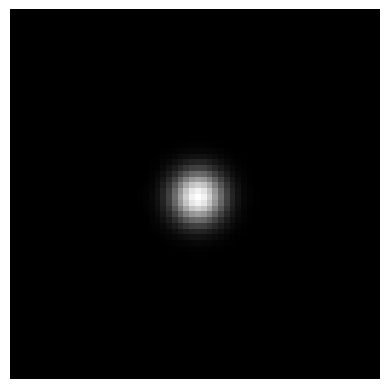

In [50]:
plt.imshow(s, cmap='gray')
plt.axis('off')

In [36]:
s.min()

np.float32(0.0)

In [37]:
noise = np.random.normal(loc=0.0, scale=20.0, size=s.shape).astype(np.float32)

In [41]:
data = s + noise

In [42]:
mu = data.mean(dtype=np.float64)
sigma = data.std(dtype=np.float64) + 1e-8
data = ((data - mu) / sigma).astype(np.float32)

In [45]:
present_data_with_signal = data_with_signal[::2]
absent_data_with_signal = data_with_signal[1::2]

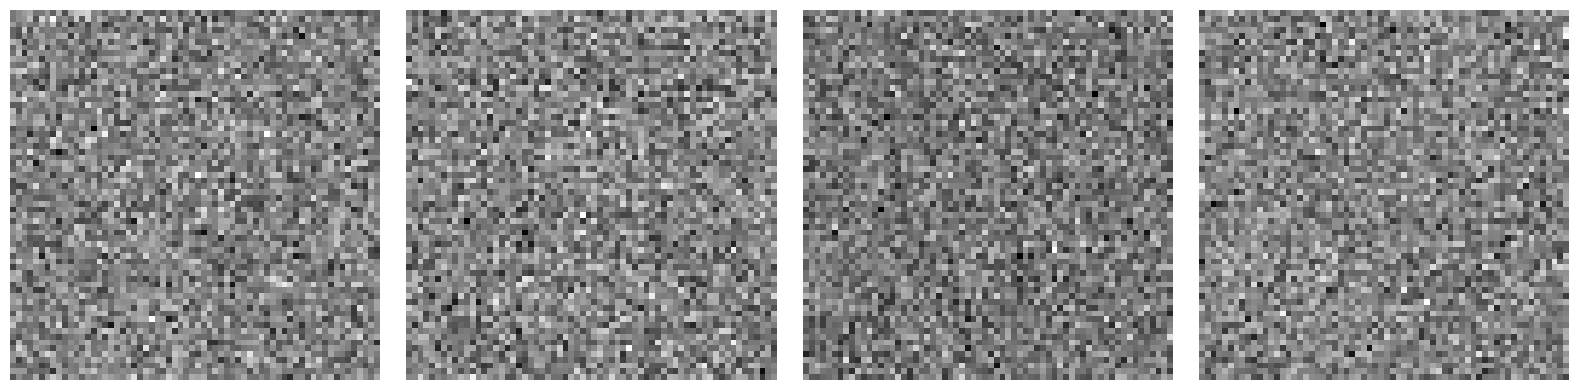

In [48]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(present_data_with_signal[i], cmap='gray')

    # Update title logic to reflect odd indexes
    original_index = i * 2 + 1
    # ax.set_title(f"Dataset Index: {original_index}")
    ax.axis('off')

plt.tight_layout()
plt.show()

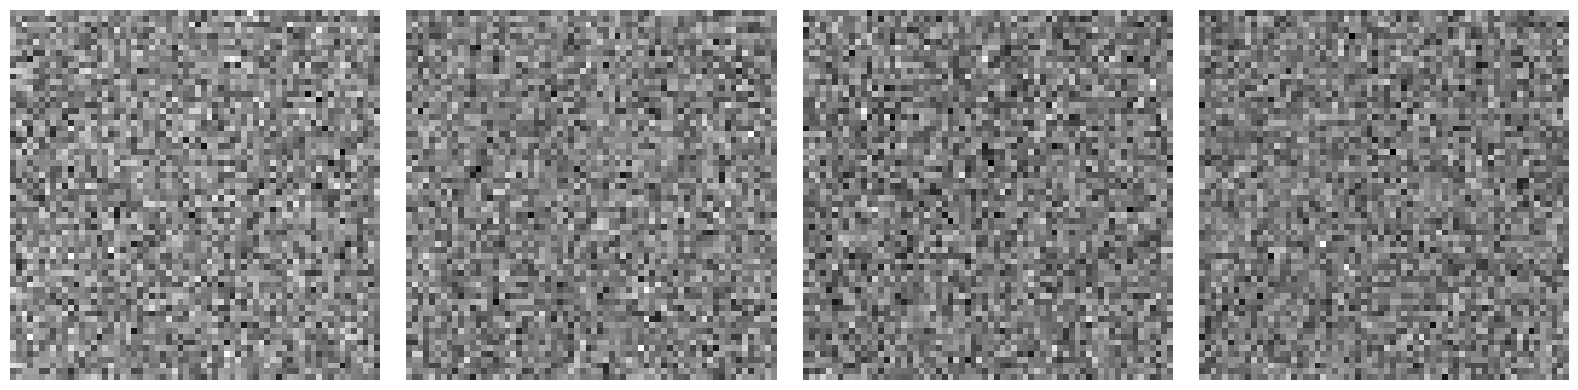

In [49]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(absent_data_with_signal[i], cmap='gray')

    # Update title logic to reflect odd indexes
    original_index = i * 2 + 1
    # ax.set_title(f"Dataset Index: {original_index}")
    ax.axis('off')

plt.tight_layout()
plt.show()

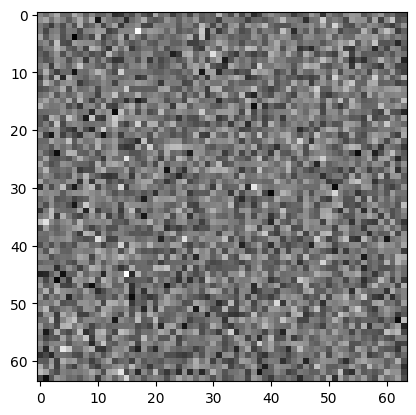

In [40]:
plt.imshow(s + noise, cmap='gray')

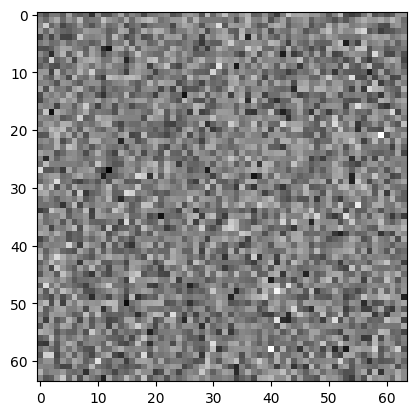

In [34]:
plt.imshow(data_with_signal[3], cmap='gray')

In [ ]:
b

In [55]:
torch.backends.cudnn.benchmark = True

# Initialize wandb
# data_name = args.data.replace('_num_signals', '')
# wandb.init(project='VIB-MRI', name = '{}'.format(args.proporation) + args.train_type + args.cls_type + data_name, mode='online',
#            settings=wandb.Settings(_service_wait=120))

# device = torch.device(device)

# if args.train_type == 'recon':
#     model = UNet(n_channels=1, n_classes=1, bilinear=True).to(device)
#
#     # Load the model and use multi-GPU
#     if args.data_parallel:
#         model = nn.DataParallel(model)
#     print(device)
#
#     # for re-train?
#     # load_model(model, os.path.join(args.save_model_path, args.srtype) + '/srnet.pth')
#
# if not os.path.exists(args.save_model_path):
#     os.makedirs(args.save_model_path)

# sks_3_c3_num_signals -> num_classes = 3  "detect 'c3"
# if 'c3' in args.data:
#     if args.cls_type == 'ResNet':
#         cls_model = ResNetX(args.depth, num_classes=3).to(device)
#     elif args.cls_type == 'CNN':
#         cls_model = BinaryClassifier(args.depth, num_classes=3).to(device)
#     elif args.cls_type == 'VIBCNN':
#         cls_model = VIBCNN(args.depth, num_classes=3).to(device)
# if 'c2' in args.data:
#     if args.cls_type == 'ResNet':
#         cls_model = ResNetX(args.depth, num_classes=2).to(device)
#     elif args.cls_type == 'CNN':
#         cls_model = BinaryClassifier(args.depth, num_classes=2).to(device)
#     # elif args.cls_type == 'HO':
#     #     cls_model = SLNNHO().to(device)
#     # elif args.cls_type == 'VIBHO':
#     #     cls_model = VIBHO().to(device)
#     elif args.cls_type == 'VIBCNN':
depth = 4
z_dim = 16
# data = 'sks_3.0_0.2_25.0_c2_num_signals_diffusion_n'
# data = 'ske_3.0_0.05_35.0_c2_num_signals_diffusion_n'
data = 'ske_3_0.03_35_c2_num_signals'

train_image_path = '/shared/anastasio-s2/SI/HCP_selected/{}/train/data.h5'.format(data)
val_image_path = '/shared/anastasio-s2/SI/HCP_selected/{}/val/data.h5'.format(data)
test_image_path = '/shared/anastasio-s2/SI/HCP_selected/{}/test/data.h5'.format(data)

# train_image_path = '/scratch/HCP_selected/{}/val/data.h5'.format(data)
# test_image_path = '/scratch/HCP_selected/{}/test/data.h5'.format(data)


# Should be checked
train_dataset = MRIDataset1(train_image_path, proportion=0.1)
val_dataset = MRIDataset1(val_image_path, proportion=0.1)
test_dataset = MRIDataset1(test_image_path, proportion=0.1)

train_dataloader = DataLoader(
    train_dataset,  # Your dataset
    batch_size=8,  # Batch size (samples per batch)
    shuffle=False,  # Whether to shuffle data
    drop_last=True,  # Drop incomplete batches
    num_workers=8,  # Number of CPU processes for data reading
    # pin_memory=True,  # Accelerate CPU->GPU copy
    # persistent_workers=True,  # Workers do not restart repeatedly
    # prefetch_factor=8  # How many batches to prefetch
)

val_dataloader = DataLoader(
    val_dataset,  # Your dataset
    batch_size=8,  # Batch size (samples per batch)
    shuffle=False,  # Whether to shuffle data
    drop_last=True,  # Drop incomplete batches
    num_workers=8,  # Number of CPU processes for data reading
    # pin_memory=True,  # Accelerate CPU->GPU copy
    # persistent_workers=True,  # Workers do not restart repeatedly
    # prefetch_factor=8  # How many batches to prefetch
)

test_dataloader = DataLoader(
    test_dataset,  # Your dataset
    batch_size=8,  # Batch size (samples per batch)
    shuffle=False,  # Whether to shuffle data
    drop_last=True,  # Drop incomplete batches
    num_workers=8,  # Number of CPU processes for data reading
    # pin_memory=True,  # Accelerate CPU->GPU copy
    # persistent_workers=True,  # Workers do not restart repeatedly
    # prefetch_factor=8  # How many batches to prefetch
)

AssertionError: 

In [62]:
import h5py

data = 'ske_3_0.08_25_c2_num_signals'

train_image_path = '/shared/anastasio-s2/SI/HCP_selected/{}/train/data.h5'.format(data)

with h5py.File(train_image_path, "r") as f:
    ds = f["data_with_signal"]
    total_length = int(len(ds))

In [66]:
total_length // 2

8904

In [12]:
import numpy as np

a = np.load('/shared/anastasio-s2/SI/HCP_selected/HCP_selected_ones2.npy', mmap_mode='r')

In [13]:
a.shape

(11130, 260, 311)

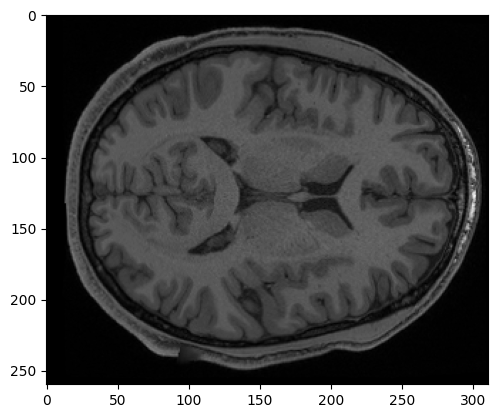

In [14]:
import matplotlib.pyplot as plt

plt.imshow(a[0], cmap='gray')

In [53]:
len(train_dataset)

34318

In [20]:
train_ = iter(train_dataloader)
valid_ = iter(val_dataloader)
test_ = iter(test_dataloader)

In [21]:
img, measure, label = next(train_)
img_val, measure_val, label_val = next(valid_)
img_test, measure_test, label_test = next(test_)

In [23]:
import numpy as np

train_bg_path  = "/shared/anastasio-s2/SOM/kaiyan/mri_1000_200k/background_train.npy"

bg_data = np.load(train_bg_path, mmap_mode='r')
# bg_data = bg_data.reshape(-1, bg_data.shape[1], bg_data.shape[2]).astype(np.float32)

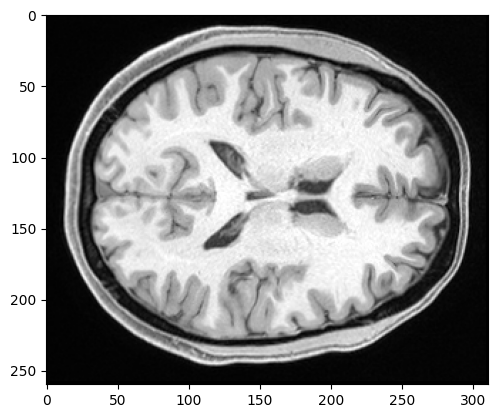

In [26]:
plt.imshow(bg_data[0][:, :, 0], cmap='gray')

In [40]:
bg_data.shape

(171592, 260, 311, 1)

In [41]:
test_bg_path  = "/shared/anastasio-s2/SOM/kaiyan/mri_1000_200k/background_test.npy"

bg_data_test = np.load(test_bg_path, mmap_mode='r')
# bg_data = bg_data.reshape(-1, bg_data.shape[1], bg_data.shape[2]).astype(np.float32)

In [47]:
bg_data_test.shape

(10000, 260, 311, 1)

In [48]:
def as_void(arr):
    arr = np.ascontiguousarray(arr)
    return arr.view(np.dtype((np.void, arr.dtype.itemsize * arr.shape[1])))

bg_data_flat = bg_data.reshape(bg_data.shape[0], -1)
bg_data_test_flat = bg_data_test.reshape(bg_data_test.shape[0], -1)

void_B = as_void(bg_data_test_flat)

In [50]:
found_mask = np.zeros(len(bg_data_test), dtype=bool)

chunk_size = 10000

for i in range(0, len(bg_data), chunk_size):
    chunk_4d = bg_data[i:i + chunk_size]

    chunk_flat = chunk_4d.reshape(chunk_4d.shape[0], -1)

    void_chunk = as_void(chunk_flat)
    match_in_chunk = np.in1d(void_B, void_chunk)

    found_mask |= match_in_chunk

    print(f'Processed {i} ~ {i+len(chunk_4d)}...')

Processed 0 ~ 10000...
Processed 10000 ~ 20000...
Processed 20000 ~ 30000...
Processed 30000 ~ 40000...
Processed 40000 ~ 50000...
Processed 50000 ~ 60000...
Processed 60000 ~ 70000...
Processed 70000 ~ 80000...
Processed 80000 ~ 90000...
Processed 90000 ~ 100000...
Processed 100000 ~ 110000...
Processed 110000 ~ 120000...
Processed 120000 ~ 130000...
Processed 130000 ~ 140000...
Processed 140000 ~ 150000...
Processed 150000 ~ 160000...
Processed 160000 ~ 170000...
Processed 170000 ~ 171592...


In [51]:
duplicates = bg_data_test[found_mask]
len(duplicates)

0

In [210]:
bg = bg_data[0].copy()

In [244]:
from numpy.fft import fft2, ifft2, fftshift, ifftshift
mask = np.ones((260, 311), dtype=np.float32)

In [245]:
img_neg = bg.copy()

kspace_neg = fft2(img_neg)
kspace_neg_shifted = fftshift(kspace_neg)

In [262]:
np.random.normal(0, 25, size=kspace_neg.shape)

array([[-21.35304316, -19.0226333 ,  27.92933783, ...,  39.30650964,
         -8.79742012,  -1.80450591],
       [ 17.60349322,   5.05354534,  11.96641519, ..., -16.64913553,
         30.17300862, -13.72005009],
       [-21.85109477,  -1.62379382,   1.08727327, ..., -43.6898352 ,
        -36.21735586,  31.24486672],
       ...,
       [ -6.407575  ,  -0.90485565, -29.08640382, ...,  39.47810901,
          8.47958112,  37.43565527],
       [ 22.90183766,   1.95238208,  16.77587845, ...,   7.47354128,
          0.58640212, -32.62279843],
       [  4.70840557,  21.81651407, -29.23562164, ..., -12.28144997,
        -23.16646211, -16.62854353]])

In [267]:
img_neg = bg.copy()

kspace_neg = fft2(img_neg)
kspace_neg_shifted = fftshift(kspace_neg)

# noise_real_neg = np.random.normal(0, 25, size=kspace_neg.shape)
# noise_imag_neg = np.random.normal(0, 25, size=kspace_neg.shape)
# noise_neg = noise_real_neg + 1j * noise_imag_neg
noise_neg = np.random.normal(0, 25, size=kspace_neg.shape)

kspace_neg_noisy = kspace_neg + noise_neg
kspace_neg_noisy = kspace_neg_noisy * mask

kspace_neg_noisy = kspace_neg_shifted + noise_neg
kspace_neg_noisy = kspace_neg_noisy * mask
kspace_neg_noisy = ifftshift(kspace_neg_noisy)

img_neg_recon = ifft2(kspace_neg_noisy)
# img_neg_recon_abs = np.abs(img_neg_recon).astype(np.float32)

In [295]:
H, W = 260, 311
X, Y = np.meshgrid(np.arange(W), np.arange(H))

y0 = 170
x0 = 180

signal = 0.2 * np.exp(
    -0.5 * (((X - x0) ** 2 + (Y - y0) ** 2) / (3 ** 2))
)

distance = np.sqrt((X - x0) ** 2 + (Y - y0) ** 2)
within_3sigma = distance <= 3 * 2

signal2 = np.zeros_like(bg)
signal2[within_3sigma] = 0.2 * np.exp(-0.5 * ((X[within_3sigma] - x0) ** 2 + (Y[within_3sigma] - y0) ** 2) / (3 ** 2))

# img_pos = bg + signal.astype(np.float32)

In [6]:
mri_loc = np.load('./data/mri_loc.npy')

In [8]:
mri_loc

(32274, 2)

In [18]:
mri_loc[7]

array([ 36., 149.])

In [ ]:
plt.imshow()

In [304]:
mri_loc[:, 0].min(), mri_loc[:, 0].max()

(35.0, 223.0)

In [305]:
mri_loc[:, 1].min(), mri_loc[:, 1].max()

(39.0, 278.0)

In [318]:
272 / 16

17.0

In [343]:
def zero_padding(image):
    # 260 x 311 -> 288 x 320
    # image = np.pad(image, ((0,0),(14,14),(4,5)), 'constant')
    image = np.pad(image, ((0, 12),(4, 5)), 'constant')
    print(image.shape)
    return image

In [345]:
seg = zero_padding(bg)

(272, 320)


In [346]:
seg[seg < 2100] = 0
seg[seg > 5001] = 0
seg[seg > 0] = 1

In [369]:
np.unique(seg, return_counts=True)

(array([0., 1.]), array([725473286, 174498514]))

In [ ]:
'/shared/ana'

In [350]:
seg = np.load('/shared/anastasio-s2/SI/HCP_selected/HCP_selected_ones2_wmparc.npy')

In [352]:
seg[seg < 2100] = 0
seg[seg > 5001] = 0
seg[seg > 0] = 1

In [354]:
overlap_mask = np.all(seg == 1, axis=0)

In [359]:
white_matter_coords = np.argwhere(seg == 1)

In [365]:
mri_loc.shape

(32274, 2)

In [370]:
white_matter_coords.

(174498514, 3)

In [364]:
white_matter_coords[3]

array([  0,  31, 139])

In [294]:
signal.mean(), signal2.mean()

(0.00013986808747122503, 0.00012084261)

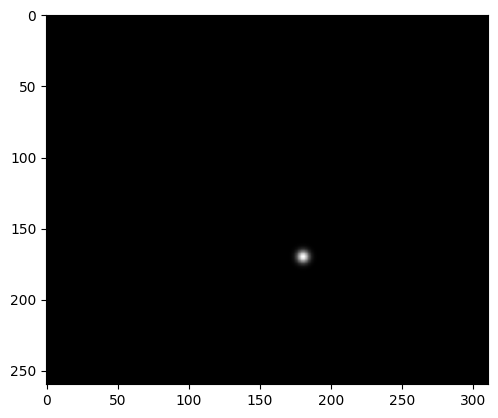

In [288]:
plt.imshow(signal, cmap='gray')

In [282]:
kspace_neg = fft2(img_pos)
kspace_neg_shifted = fftshift(kspace_neg)

# noise_real_neg = np.random.normal(0, 25, size=kspace_neg.shape)
# noise_imag_neg = np.random.normal(0, 25, size=kspace_neg.shape)
# noise_neg = noise_real_neg + 1j * noise_imag_neg
noise_neg = np.random.normal(0, 25, size=kspace_neg.shape)

kspace_neg_noisy = kspace_neg + noise_neg
kspace_neg_noisy = kspace_neg_noisy * mask

kspace_neg_noisy = kspace_neg_shifted + noise_neg
kspace_neg_noisy = kspace_neg_noisy * mask
kspace_neg_noisy = ifftshift(kspace_neg_noisy)

img_neg_recon = ifft2(kspace_neg_noisy)

In [285]:
np.abs(img_neg_recon.real).min(), np.abs(img_neg_recon.real).max()

(2.8535811935626043e-08, 0.9518877292460552)

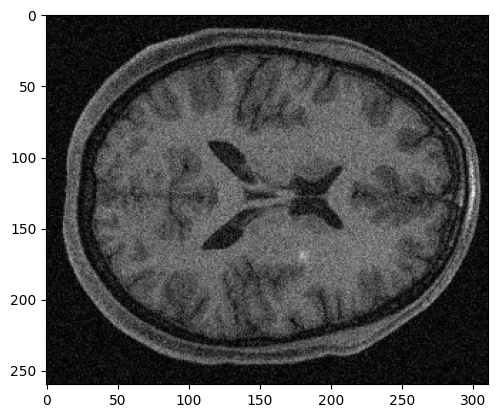

In [284]:
plt.imshow(np.abs(img_neg_recon.real), cmap='gray')

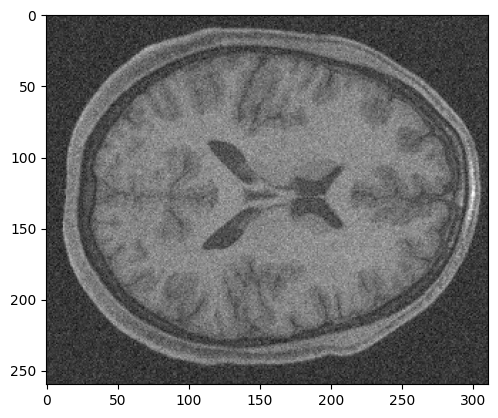

In [280]:
plt.imshow(img_neg_recon.real, cmap='gray')

In [279]:
img_neg_recon.real

(260, 311)

In [278]:
np.stack((img_neg_recon.real, img_neg_recon.imag), axis=1).shape

(260, 2, 311)

array([[0.04899687, 0.07830495, 0.08092784, ..., 0.06659965, 0.08092784,
        0.07830495],
       [0.04315017, 0.07068651, 0.01369253, ..., 0.02915371, 0.06042225,
        0.04466149],
       [0.05697227, 0.15963034, 0.05017033, ..., 0.06382625, 0.07058021,
        0.03184185],
       ...,
       [0.05211245, 0.04058808, 0.0527025 , ..., 0.06462541, 0.11939766,
        0.05420689],
       [0.05697227, 0.03184185, 0.07144172, ..., 0.07795001, 0.05017033,
        0.15963034],
       [0.04315017, 0.04466149, 0.06042225, ..., 0.08242457, 0.01369253,
        0.07068651]])

In [273]:
img_neg_recon[0][0]

(0.04899687410493004+2.3752367594143974e-18j)

In [272]:
np.abs(img_neg_recon).astype(np.float32)[0][0]

0.048996873

In [264]:
kspace_neg = fft2(img_neg)
print(kspace_neg.mean(), kspace_neg.mean())
kspace_neg_shifted = fftshift(kspace_neg)
print(kspace_neg_shifted.mean(), kspace_neg_shifted.mean())

(0.003921568859368595-1.4938444852735226e-17j) (0.003921568859368595-1.4938444852735226e-17j)
(0.003921568859368541+3.7346112131838065e-18j) (0.003921568859368541+3.7346112131838065e-18j)


In [257]:
img_neg_recon.min(), img_neg_recon.max()

((-0.33284309569919485+0.08972795869664153j),
 (0.984144499800474-0.05788304350451153j))

In [259]:
img_neg_recon.min(), img_neg_recon.max()

((-0.3346527423756983-0.08586417564677454j),
 (0.9798217149354241-0.0691195261180722j))

/tmp/ipykernel_3298529/2160570743.py:1: ComplexWarning: Casting complex values to real discards the imaginary part
  plt.imshow(img_neg_recon.astype(np.float32), cmap='gray')


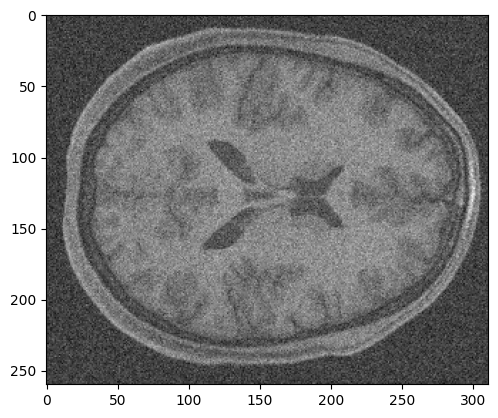

In [253]:
plt.imshow(img_neg_recon.astype(np.float32), cmap='gray')

/tmp/ipykernel_3298529/2160570743.py:1: ComplexWarning: Casting complex values to real discards the imaginary part
  plt.imshow(img_neg_recon.astype(np.float32), cmap='gray')


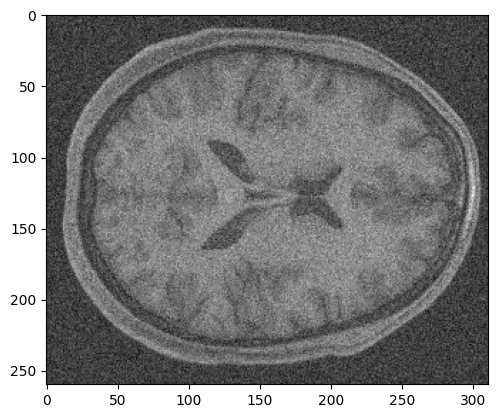

In [241]:
plt.imshow(img_neg_recon.astype(np.float32), cmap='gray')

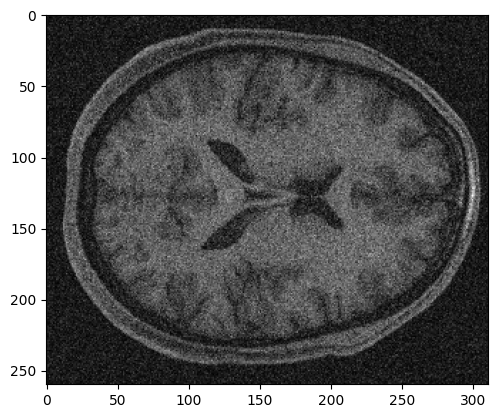

In [242]:
plt.imshow(img_neg_recon_abs.astype(np.float32), cmap='gray')

In [31]:
img, measure, label = next(train_)
img_test, measure_test, label_test = next(test_)

In [38]:
measure.mean(), measure_test.mean()

(tensor(0.2226), tensor(0.2405))

In [24]:
import h5py

with h5py.File(train_image_path, "r") as f:
    all_labels = f['label'][:train_dataset.selected_length]

class_counts = np.bincount(all_labels)
weights = 1. / class_counts
samples_weights = torch.from_numpy(weights[all_labels])
# sampler = WeightedRandomSampler(samples_weights, len(samples_weights))

In [15]:
if train_dataset.label_ds is None:
    print("Labels are missing! Check your dataset loading logic.")

Labels are missing! Check your dataset loading logic.


In [8]:
class_counts = torch.bincount(torch.tensor(train_dataset.label_ds))

RuntimeError: Could not infer dtype of NoneType

In [40]:
k = iter(train_dataloader)
img, measure, label = next(k)

In [41]:
img, measure, label = next(k)

In [42]:
img = img.cpu().numpy()
measure = measure.cpu().numpy()
label = label.cpu().numpy()

In [43]:
img.min(), img.max()

(0.0, 0.77777773)

In [45]:
label

array([0, 1, 0, 0])

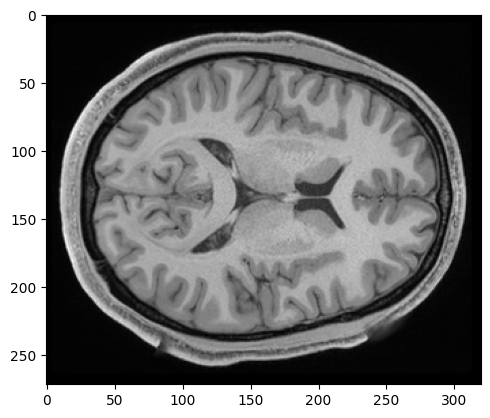

In [46]:
plt.imshow(img[0][0], cmap='gray')

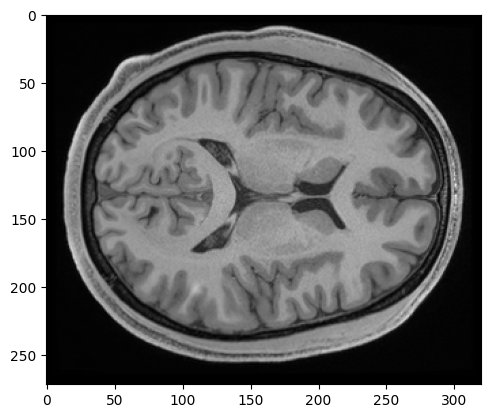

In [47]:
plt.imshow(img[1][0], cmap='gray')

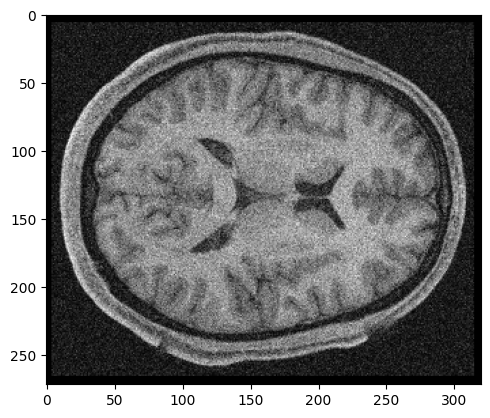

In [48]:
plt.imshow(measure[0][0], cmap='gray')

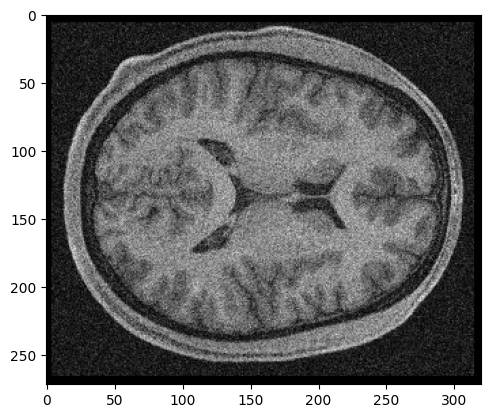

In [49]:
plt.imshow(measure[1][0], cmap='gray')

48


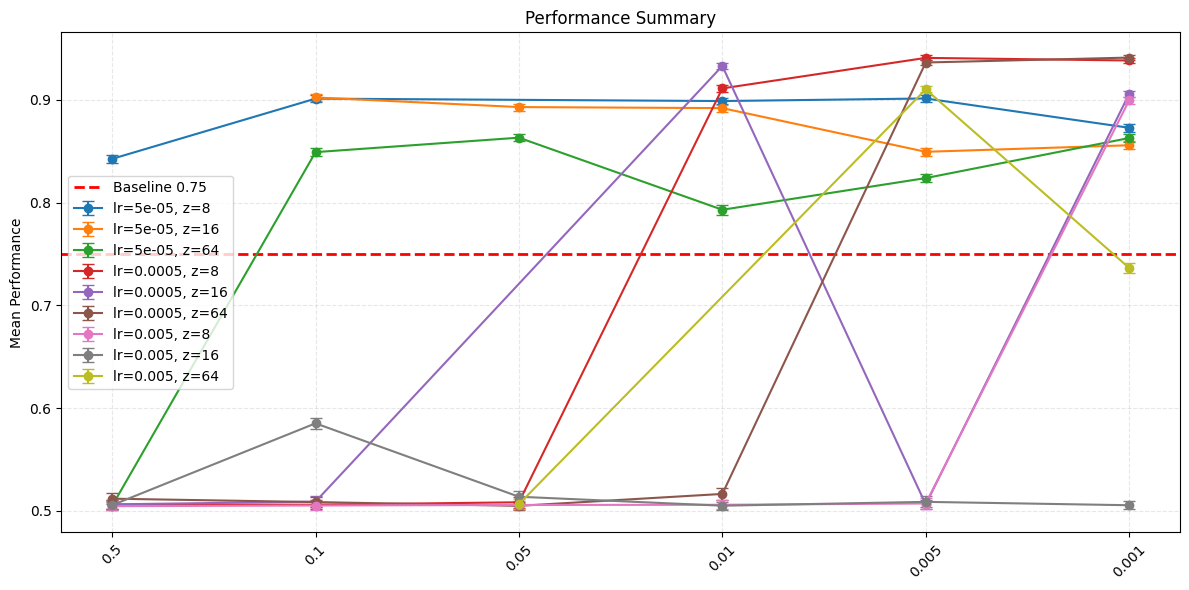

In [374]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Your data
raw_data = """VIB-CE-lr0.005-depth4-z8-kl0.1,0.505341,0.0039131100932911
VIB-CE-lr0.005-depth4-z8-kl0.5,0.504692,0.0034492024505075
VIB-CE-lr0.005-depth4-z8-kl0.01,0.506045,0.0044074290287801
VIB-CE-lr0.005-depth4-z8-kl0.05,0.505852,0.004280169021746
VIB-CE-lr0.005-depth4-z8-kl0.001,0.899573,0.0032546286596382
VIB-CE-lr0.005-depth4-z8-kl0.005,0.507286,0.0049468599217914
VIB-CE-lr0.0005-depth4-z8-kl0.1,0.506126,0.00448636852677
VIB-CE-lr0.0005-depth4-z8-kl0.5,0.506306,0.004369781337757
VIB-CE-lr0.0005-depth4-z8-kl0.01,0.911227,0.0031283282786377
VIB-CE-lr0.0005-depth4-z8-kl0.05,0.508482,0.0051177972488955
VIB-CE-lr0.0005-depth4-z8-kl0.001,0.938393,0.0025679525147614
VIB-CE-lr0.0005-depth4-z8-kl0.005,0.940924,0.0024402353141409
VIB-CE-lr5e-05-depth4-z8-kl0.1,0.901282,0.0032202733920567
VIB-CE-lr5e-05-depth4-z8-kl0.5,0.842652,0.0040062751579877
VIB-CE-lr5e-05-depth4-z8-kl0.01,0.898923,0.0033492178736248
VIB-CE-lr5e-05-depth4-z8-kl0.001,0.87292,0.0036379223052689
VIB-CE-lr5e-05-depth4-z8-kl0.005,0.901426,0.0032472070922469
VIB-CE-lr0.005-depth4-z16-kl0.1,0.585302,0.0053324055696761
VIB-CE-lr0.005-depth4-z16-kl0.5,0.505687,0.0039567668006994
VIB-CE-lr0.005-depth4-z16-kl0.01,0.505146,0.003791884449733
VIB-CE-lr0.005-depth4-z16-kl0.05,0.513863,0.0056507658213467
VIB-CE-lr0.005-depth4-z16-kl0.001,0.505611,0.0040974567550487
VIB-CE-lr0.005-depth4-z16-kl0.005,0.508885,0.0052451468937158
VIB-CE-lr0.0005-depth4-z16-kl0.1,0.509117,0.005018527747345
VIB-CE-lr0.0005-depth4-z16-kl0.5,0.506445,0.004571012136615
VIB-CE-lr0.0005-depth4-z16-kl0.01,0.933092,0.0025957382282674
VIB-CE-lr0.0005-depth4-z16-kl0.001,0.905834,0.0030286531874173
VIB-CE-lr0.0005-depth4-z16-kl0.005,0.506414,0.0043872487796293
VIB-CE-lr5e-05-depth4-z16-kl0.1,0.902387,0.0032265772451357
VIB-CE-lr5e-05-depth4-z16-kl0.01,0.892031,0.0034583479158124
VIB-CE-lr5e-05-depth4-z16-kl0.05,0.893064,0.0033987211750545
VIB-CE-lr5e-05-depth4-z16-kl0.001,0.855908,0.0040224268111724
VIB-CE-lr5e-05-depth4-z16-kl0.005,0.849531,0.0039189849227401
VIB-CE-lr0.005-depth4-z64-kl0.05,0.50672,0.0046779124008434
VIB-CE-lr0.005-depth4-z64-kl0.001,0.73653,0.0049754432808964
VIB-CE-lr0.005-depth4-z64-kl0.005,0.910336,0.0030692439773812
VIB-CE-lr0.0005-depth4-z64-kl0.1,0.508673,0.0050515272738106
VIB-CE-lr0.0005-depth4-z64-kl0.5,0.511989,0.0056041147613913
VIB-CE-lr0.0005-depth4-z64-kl0.01,0.516602,0.0057263544543023
VIB-CE-lr0.0005-depth4-z64-kl0.05,0.505007,0.0037380243694727
VIB-CE-lr0.0005-depth4-z64-kl0.001,0.941218,0.0024539748826782
VIB-CE-lr0.0005-depth4-z64-kl0.005,0.936436,0.002616173529973
VIB-CE-lr5e-05-depth4-z64-kl0.1,0.849211,0.0039519904508064
VIB-CE-lr5e-05-depth4-z64-kl0.5,0.505043,0.0037203486345896
VIB-CE-lr5e-05-depth4-z64-kl0.01,0.793123,0.0046670336421705
VIB-CE-lr5e-05-depth4-z64-kl0.05,0.863285,0.0036667192628299
VIB-CE-lr5e-05-depth4-z64-kl0.001,0.86294,0.003776899422262
VIB-CE-lr5e-05-depth4-z64-kl0.005,0.82396,0.004281007127735229"""

lines = raw_data.strip().split('\n')
parsed_data = []
print(len(lines))
# Parse the data
for line in lines:
    parts = line.split(',')
    config_str = parts[0]
    mean_val = float(parts[1])
    std_val = float(parts[2])

    # Extract parameters
    lr_val = float(re.search(r'lr(.+?)-d', config_str).group(1))
    kl_val = float(re.search(r'kl(.+?)$', config_str).group(1))
    z_val = int(re.search(r'z(.+?)-', config_str).group(1))

    parsed_data.append({
        'lr': lr_val,
        'kl': kl_val,
        'z': z_val,
        'mean': mean_val,
        'std': std_val
    })

df = pd.DataFrame(parsed_data)

# Create a categorical index for KL values (sorted descending)
# This removes the numerical "x-axis" and replaces it with even steps
unique_kls = sorted(df['kl'].unique(), reverse=True)
kl_map = {kl: i for i, kl in enumerate(unique_kls)}
df['kl_index'] = df['kl'].map(kl_map)

# Plotting
plt.figure(figsize=(12, 6))

# Plot each group as a separate line
groups = df.groupby(['lr', 'z'])
for (lr, z), group_df in groups:
    # Sort by the categorical index to ensure lines connect correctly
    group_df = group_df.sort_values('kl_index')

    label = f'lr={lr}, z={z}'
    plt.errorbar(group_df['kl_index'], group_df['mean'], yerr=group_df['std'],
                 label=label, marker='o', capsize=4, linewidth=1.5)

# Add baseline
plt.axhline(y=0.75, color='red', linestyle='--', linewidth=2, label='Baseline 0.75')

# Customize axes
plt.xticks(ticks=range(len(unique_kls)), labels=[str(k) for k in unique_kls], rotation=45)
plt.ylabel('Mean Performance')
plt.title('Performance Summary')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [376]:
# VIB-IO Dataset proporation,1.0,1.0_std

raw_data = '''
VIB-IO-lr0.0005-depth4-kl100.0-z168-ioloss1.0,0.50883,0.0051976254107962
VIB-IO-lr0.0005-depth4-kl10.0-z168-ioloss1.0,0.504838,0.0037484066137109
VIB-IO-lr0.0005-depth4-kl1.0-z168-ioloss1.0,0.504565,0.0034196611892541
VIB-IO-lr0.0005-depth4-kl0.1-z168-ioloss1.0,0.513061,0.0056904888762218
VIB-IO-lr0.0005-depth4-kl0.01-z168-ioloss1.0,0.505607,0.0040850666227092
VIB-IO-lr0.0005-depth4-kl0.001-z168-ioloss1.0,0.504725,0.0034703125072877
VIB-IO-lr0.0005-depth4-kl0.0001-z168-ioloss1.0,0.505177,0.0039042594135038
VIB-IO-lr0.0005-depth4-kl1e-08-z168-ioloss1.0,0.535301,0.0055871640555699
VIB-IO-lr0.005-depth4-kl100.0-z168-ioloss1.0,0.51664,0.0057686985948182
VIB-IO-lr0.005-depth4-kl10.0-z168-ioloss1.0,0.507863,0.0047573847713405
VIB-IO-lr0.005-depth4-kl1.0-z168-ioloss1.0,0.510887,0.0056262676502038
VIB-IO-lr0.005-depth4-kl0.1-z168-ioloss1.0,0.645206,0.0055564526606419
VIB-IO-lr0.005-depth4-kl0.01-z168-ioloss1.0,0.508351,0.0050700124079966
VIB-IO-lr0.005-depth4-kl0.001-z168-ioloss1.0,0.505081,0.0038877286955079
VIB-IO-lr0.005-depth4-kl0.0001-z168-ioloss1.0,0.855624,0.0039649008423966
VIB-IO-lr0.005-depth4-kl1e-05-z168-ioloss1.0,0.514281,0.0059093120769994
VIB-IO-lr0.005-depth4-kl1e-08-z168-ioloss1.0,0.553465,0.00572142615454
VIB-IO-lr0.005-depth4-kl10.0-z64-ioloss1.0,0.506495,0.0046186885620715
VIB-IO-lr0.005-depth4-kl100.0-z8-ioloss1.0,0.504719,0.0035636963252591
VIB-IO-lr0.005-depth4-kl10.0-z8-ioloss1.0,0.504871,0.0036529094253245
VIB-IO-lr0.005-depth4-kl1.0-z8-ioloss1.0,0.507587,0.004901018925759
VIB-IO-lr0.005-depth4-kl0.1-z8-ioloss1.0,0.504922,0.0036908419568325
VIB-IO-lr0.005-depth4-kl0.01-z8-ioloss1.0,0.504734,0.0036266235503566
VIB-IO-lr0.005-depth4-kl0.001-z8-ioloss1.0,0.510179,0.0054334418187259
VIB-IO-lr0.005-depth4-kl0.0001-z8-ioloss1.0,0.514969,0.0057385077429053
VIB-IO-lr0.005-depth4-kl1e-05-z8-ioloss1.0,0.516513,0.0057573368523948
VIB-IO-lr0.005-depth4-kl1e-08-z8-ioloss1.0,0.504735,0.0036415448057485

VIB-IO-lr5e-05-depth4-kl100.0-z128-ioloss1.0,0.506294,0.0045949451873398
VIB-IO-lr5e-05-depth4-kl10.0-z128-ioloss1.0,0.573085,0.0055959663119687
VIB-IO-lr5e-05-depth4-kl1.0-z128-ioloss1.0,0.867741,0.0037205074152675
VIB-IO-lr5e-05-depth4-kl0.1-z128-ioloss1.0,0.867747,0.003706127058066
VIB-IO-lr5e-05-depth4-kl0.01-z128-ioloss1.0,0.854849,0.0039291929221733
VIB-IO-lr5e-05-depth4-kl0.001-z128-ioloss1.0,0.839172,0.0041126096580518
VIB-IO-lr5e-05-depth4-kl0.0001-z128-ioloss1.0,0.514863,0.0057252745231591
VIB-IO-lr5e-05-depth4-kl1e-05-z128-ioloss1.0,0.847682,0.0039900749089775
VIB-IO-lr5e-05-depth4-kl1e-08-z128-ioloss1.0,0.80781,0.0044428795721178
VIB-IO-lr0.0005-depth4-kl100.0-z128-ioloss1.0,0.506124,0.0043067303806988
VIB-IO-lr0.0005-depth4-kl10.0-z128-ioloss1.0,0.504781,0.0036061827937795
VIB-IO-lr0.0005-depth4-kl1.0-z128-ioloss1.0,0.508119,0.0048853289893732
VIB-IO-lr0.0005-depth4-kl0.1-z128-ioloss1.0,0.505978,0.0043414595521645
VIB-IO-lr0.0005-depth4-kl0.01-z128-ioloss1.0,0.504931,0.0035522675252155
VIB-IO-lr0.0005-depth4-kl0.001-z128-ioloss1.0,0.506361,0.0044928636099
VIB-IO-lr0.0005-depth4-kl0.0001-z128-ioloss1.0,0.511044,0.0055774161219209
VIB-IO-lr0.0005-depth4-kl1e-05-z128-ioloss1.0,0.505571,0.0041526451752453
VIB-IO-lr0.0005-depth4-kl1e-08-z128-ioloss1.0,0.505511,0.0041763134719503
VIB-IO-lr0.005-depth4-kl100.0-z128-ioloss1.0,0.547478,0.005859984582472
VIB-IO-lr0.005-depth4-kl10.0-z128-ioloss1.0,0.512449,0.0055964763879819
VIB-IO-lr0.005-depth4-kl1.0-z128-ioloss1.0,0.506475,0.0045950622268864
VIB-IO-lr0.005-depth4-kl0.1-z128-ioloss1.0,0.681486,0.0054022334406762
VIB-IO-lr0.005-depth4-kl0.01-z128-ioloss1.0,0.513374,0.0057192450660416
VIB-IO-lr0.005-depth4-kl0.001-z128-ioloss1.0,0.50666,0.004719423388632
VIB-IO-lr0.005-depth4-kl0.0001-z128-ioloss1.0,0.516998,0.005677294748136
VIB-IO-lr0.005-depth4-kl1e-05-z128-ioloss1.0,0.515781,0.005923590577979
VIB-IO-lr0.005-depth4-kl1e-08-z128-ioloss1.0,0.515456,0.005912895631017
VIB-IO-lr0.005-depth4-kl100.0-z64-ioloss1.0,0.518841,0.0058967858784745

VIB-IO-lr0.0005-depth4-kl100.0-z168-ioloss1.0,0.50883,0.0051976254107962
VIB-IO-lr0.0005-depth4-kl10.0-z168-ioloss1.0,0.504838,0.0037484066137109
VIB-IO-lr0.0005-depth4-kl1.0-z168-ioloss1.0,0.504565,0.0034196611892541
VIB-IO-lr0.0005-depth4-kl0.1-z168-ioloss1.0,0.513061,0.0056904888762218
VIB-IO-lr0.0005-depth4-kl0.01-z168-ioloss1.0,0.505607,0.0040850666227092
VIB-IO-lr0.0005-depth4-kl0.001-z168-ioloss1.0,0.504725,0.0034703125072877
VIB-IO-lr0.0005-depth4-kl0.0001-z168-ioloss1.0,0.505177,0.0039042594135038
VIB-IO-lr0.0005-depth4-kl1e-08-z168-ioloss1.0,0.535301,0.0055871640555699
VIB-IO-lr0.005-depth4-kl100.0-z168-ioloss1.0,0.51664,0.0057686985948182
VIB-IO-lr0.005-depth4-kl10.0-z168-ioloss1.0,0.507863,0.0047573847713405
VIB-IO-lr0.005-depth4-kl1.0-z168-ioloss1.0,0.510887,0.0056262676502038
VIB-IO-lr0.005-depth4-kl0.1-z168-ioloss1.0,0.645206,0.0055564526606419
VIB-IO-lr0.005-depth4-kl0.01-z168-ioloss1.0,0.508351,0.0050700124079966
VIB-IO-lr0.005-depth4-kl0.001-z168-ioloss1.0,0.505081,0.0038877286955079
VIB-IO-lr0.005-depth4-kl0.0001-z168-ioloss1.0,0.855624,0.0039649008423966
VIB-IO-lr0.005-depth4-kl1e-05-z168-ioloss1.0,0.514281,0.0059093120769994
VIB-IO-lr0.005-depth4-kl1e-08-z168-ioloss1.0,0.553465,0.00572142615454
VIB-IO-lr0.005-depth4-kl10.0-z64-ioloss1.0,0.506495,0.0046186885620715

VIB-IO-lr0.005-depth4-kl100.0-z8-ioloss1.0,0.504719,0.0035636963252591
VIB-IO-lr0.005-depth4-kl10.0-z8-ioloss1.0,0.504871,0.0036529094253245
VIB-IO-lr0.005-depth4-kl1.0-z8-ioloss1.0,0.507587,0.004901018925759
VIB-IO-lr0.005-depth4-kl0.1-z8-ioloss1.0,0.504922,0.0036908419568325
VIB-IO-lr0.005-depth4-kl0.01-z8-ioloss1.0,0.504734,0.0036266235503566
VIB-IO-lr0.005-depth4-kl0.001-z8-ioloss1.0,0.510179,0.0054334418187259
VIB-IO-lr0.005-depth4-kl0.0001-z8-ioloss1.0,0.514969,0.0057385077429053
VIB-IO-lr0.005-depth4-kl1e-05-z8-ioloss1.0,0.516513,0.0057573368523948
VIB-IO-lr0.005-depth4-kl1e-08-z8-ioloss1.0,0.504735,0.0036415448057485

VIB-IO-lr5e-05-depth4-kl100.0-z8-ioloss1.0,0.504888,0.0036435230109743
VIB-IO-lr5e-05-depth4-kl10.0-z8-ioloss1.0,0.504894,0.0036478144117621
VIB-IO-lr5e-05-depth4-kl1.0-z8-ioloss1.0,0.505322,0.0038765515865443
VIB-IO-lr5e-05-depth4-kl0.1-z8-ioloss1.0,0.538086,0.0057751410723589
VIB-IO-lr5e-05-depth4-kl0.01-z8-ioloss1.0,0.510594,0.0055086897564238
VIB-IO-lr5e-05-depth4-kl0.001-z8-ioloss1.0,0.506939,0.0046259796503677
VIB-IO-lr5e-05-depth4-kl0.0001-z8-ioloss1.0,0.507642,0.0049271442373548
VIB-IO-lr5e-05-depth4-kl1e-05-z8-ioloss1.0,0.560403,0.0058665344101343
VIB-IO-lr5e-05-depth4-kl1e-08-z8-ioloss1.0,0.505986,0.0041909245430655

VIB-IO-lr0.005-depth4-kl1.0-z64-ioloss1.0,0.504833,0.0035816458711728
VIB-IO-lr0.005-depth4-kl0.1-z64-ioloss1.0,0.505297,0.0041425317634922
VIB-IO-lr0.005-depth4-kl0.01-z64-ioloss1.0,0.505033,0.0039622927655727
VIB-IO-lr0.005-depth4-kl0.001-z64-ioloss1.0,0.508354,0.0051184671386133
VIB-IO-lr0.005-depth4-kl0.0001-z64-ioloss1.0,0.512441,0.0056536936399495
VIB-IO-lr0.005-depth4-kl1e-05-z64-ioloss1.0,0.509194,0.0052296265566895
VIB-IO-lr0.005-depth4-kl1e-08-z64-ioloss1.0,0.577993,0.005426869433262506

VIB-IO-lr5e-05-depth4-kl100.0-z16-ioloss1.0,0.505584,0.0040881389548364
VIB-IO-lr5e-05-depth4-kl10.0-z16-ioloss1.0,0.505634,0.0042198063881064
VIB-IO-lr5e-05-depth4-kl1.0-z16-ioloss1.0,0.507097,0.0046880272398051
VIB-IO-lr5e-05-depth4-kl0.1-z16-ioloss1.0,0.867307,0.0037317310363593
VIB-IO-lr5e-05-depth4-kl0.01-z16-ioloss1.0,0.85434,0.0038764343755296
VIB-IO-lr5e-05-depth4-kl0.001-z16-ioloss1.0,0.509157,0.0052399611164909
VIB-IO-lr5e-05-depth4-kl0.0001-z16-ioloss1.0,0.504912,0.0036326833905938
VIB-IO-lr5e-05-depth4-kl1e-05-z16-ioloss1.0,0.509964,0.0055415536228249
VIB-IO-lr5e-05-depth4-kl1e-08-z16-ioloss1.0,0.507067,0.0047327090260613

VIB-IO-lr0.0005-depth4-kl100.0-z16-ioloss1.0,0.506938,0.004746571619878
VIB-IO-lr0.0005-depth4-kl10.0-z16-ioloss1.0,0.504774,0.0037358267701346
VIB-IO-lr0.0005-depth4-kl1.0-z16-ioloss1.0,0.510621,0.0055948619535155
VIB-IO-lr0.0005-depth4-kl0.1-z16-ioloss1.0,0.504753,0.0035603654420859
VIB-IO-lr0.0005-depth4-kl0.01-z16-ioloss1.0,0.505225,0.0039950691076131
VIB-IO-lr0.0005-depth4-kl0.001-z16-ioloss1.0,0.506505,0.0045155653149494
VIB-IO-lr0.0005-depth4-kl0.0001-z16-ioloss1.0,0.506548,0.0046105875799098
VIB-IO-lr0.0005-depth4-kl1e-05-z16-ioloss1.0,0.508609,0.0052889314947286
VIB-IO-lr0.0005-depth4-kl1e-08-z16-ioloss1.0,0.513171,0.0057613418544644

VIB-IO-lr0.005-depth4-kl100.0-z16-ioloss1.0,0.509862,0.0054085855852615
VIB-IO-lr0.005-depth4-kl1.0-z16-ioloss1.0,0.507102,0.0051097891419262
VIB-IO-lr0.005-depth4-kl0.1-z16-ioloss1.0,0.508148,0.0050239405257703
VIB-IO-lr0.005-depth4-kl0.01-z16-ioloss1.0,0.505654,0.0041218859134266
VIB-IO-lr0.005-depth4-kl0.001-z16-ioloss1.0,0.511118,0.0054333745807585
VIB-IO-lr0.005-depth4-kl0.0001-z16-ioloss1.0,0.507639,0.004970717720579
VIB-IO-lr0.005-depth4-kl1e-05-z16-ioloss1.0,0.507775,0.0050519483229563
VIB-IO-lr0.005-depth4-kl1e-08-z16-ioloss1.0,0.505428,0.0039663699796494

VIB-IO-lr5e-05-depth4-kl100.0-z64-ioloss1.0,0.506806,0.0047279559282918
VIB-IO-lr5e-05-depth4-kl10.0-z64-ioloss1.0,0.508668,0.0051667758497153
VIB-IO-lr5e-05-depth4-kl1.0-z64-ioloss1.0,0.520786,0.0056807041692611
VIB-IO-lr5e-05-depth4-kl0.1-z64-ioloss1.0,0.506389,0.004463488380163
VIB-IO-lr5e-05-depth4-kl0.01-z64-ioloss1.0,0.505592,0.0041239593826406
VIB-IO-lr5e-05-depth4-kl0.001-z64-ioloss1.0,0.507177,0.0045665813545491
VIB-IO-lr5e-05-depth4-kl0.0001-z64-ioloss1.0,0.824218,0.0043221172883798
VIB-IO-lr5e-05-depth4-kl1e-05-z64-ioloss1.0,0.51574,0.0056525722215694
VIB-IO-lr5e-05-depth4-kl1e-08-z64-ioloss1.0,0.508154,0.0050887508476632
VIB-IO-lr0.0005-depth4-kl100.0-z64-ioloss1.0,0.507897,0.005120944022556
VIB-IO-lr0.0005-depth4-kl10.0-z64-ioloss1.0,0.508118,0.0051546084249496
VIB-IO-lr0.0005-depth4-kl1.0-z64-ioloss1.0,0.515811,0.0059163157819753
VIB-IO-lr0.0005-depth4-kl0.1-z64-ioloss1.0,0.507369,0.0048581992809029
VIB-IO-lr0.0005-depth4-kl0.01-z64-ioloss1.0,0.881063,0.0035451375914384
VIB-IO-lr0.0005-depth4-kl0.001-z64-ioloss1.0,0.513947,0.0056146836348438
VIB-IO-lr0.0005-depth4-kl0.0001-z64-ioloss1.0,0.858265,0.0038439220976299
VIB-IO-lr0.0005-depth4-kl1e-05-z64-ioloss1.0,0.863801,0.0038380783558328
VIB-IO-lr0.0005-depth4-kl1e-08-z64-ioloss1.0,0.528472,0.0058162163505902
'''

In [378]:
# VIB-IO Dataset proporation,0.5,0.5_std
raw_data = '''
VIB-IO-lr5e-05-depth4-kl100.0-z128-ioloss1.0,0.504341,0.0032619050127287
VIB-IO-lr5e-05-depth4-kl10.0-z128-ioloss1.0,0.863992,0.0038415497310237
VIB-IO-lr5e-05-depth4-kl1.0-z128-ioloss1.0,0.809684,0.0043246448586994
VIB-IO-lr5e-05-depth4-kl0.1-z128-ioloss1.0,0.50756,0.0049063454552837
VIB-IO-lr5e-05-depth4-kl0.01-z128-ioloss1.0,0.515371,0.0055676001306877
VIB-IO-lr5e-05-depth4-kl0.001-z128-ioloss1.0,0.51525,0.0057609965849001
VIB-IO-lr5e-05-depth4-kl0.0001-z128-ioloss1.0,0.508684,0.0052881692360319
VIB-IO-lr5e-05-depth4-kl1e-05-z128-ioloss1.0,0.511979,0.0055935541044002
VIB-IO-lr5e-05-depth4-kl1e-08-z128-ioloss1.0,0.508921,0.0052403887408573

VIB-IO-lr0.0005-depth4-kl100.0-z128-ioloss1.0,0.506768,0.0047469215898444
VIB-IO-lr0.0005-depth4-kl10.0-z128-ioloss1.0,0.507202,0.0048884064791399
VIB-IO-lr0.0005-depth4-kl1.0-z128-ioloss1.0,0.505129,0.0038596104549005
VIB-IO-lr0.0005-depth4-kl0.1-z128-ioloss1.0,0.50469,0.0035537663816681
VIB-IO-lr0.0005-depth4-kl0.01-z128-ioloss1.0,0.509418,0.0052999179359548
VIB-IO-lr0.0005-depth4-kl0.001-z128-ioloss1.0,0.507605,0.0049592095189959
VIB-IO-lr0.0005-depth4-kl0.0001-z128-ioloss1.0,0.511842,0.005613108048569
VIB-IO-lr0.0005-depth4-kl1e-05-z128-ioloss1.0,0.573678,0.0058700269864661
VIB-IO-lr0.0005-depth4-kl1e-08-z128-ioloss1.0,0.523356,0.0059367656055923

VIB-IO-lr0.005-depth4-kl100.0-z128-ioloss1.0,0.531027,0.0056471360552649
VIB-IO-lr0.005-depth4-kl10.0-z128-ioloss1.0,0.530386,0.0057821577041692
VIB-IO-lr0.005-depth4-kl1.0-z128-ioloss1.0,0.522688,0.0057835700669404
VIB-IO-lr0.005-depth4-kl0.1-z128-ioloss1.0,0.515889,0.0058945815203102
VIB-IO-lr0.005-depth4-kl0.01-z128-ioloss1.0,0.875703,0.0035524840271109
VIB-IO-lr0.005-depth4-kl0.001-z128-ioloss1.0,0.520676,0.0057369127915294
VIB-IO-lr0.005-depth4-kl0.0001-z128-ioloss1.0,0.860297,0.0038796502484411
VIB-IO-lr0.005-depth4-kl1e-05-z128-ioloss1.0,0.858287,0.0038903571098898
VIB-IO-lr0.005-depth4-kl1e-08-z128-ioloss1.0,0.837035,0.004066159909234

VIB-IO-lr5e-05-depth4-kl100.0-z8-ioloss1.0,0.504481,0.0034311140855538
VIB-IO-lr5e-05-depth4-kl10.0-z8-ioloss1.0,0.504657,0.0035857695288662
VIB-IO-lr5e-05-depth4-kl1.0-z8-ioloss1.0,0.504953,0.0037727981838198
VIB-IO-lr5e-05-depth4-kl0.1-z8-ioloss1.0,0.508231,0.0050599015098544
VIB-IO-lr5e-05-depth4-kl0.01-z8-ioloss1.0,0.505682,0.0041875501998539
VIB-IO-lr5e-05-depth4-kl0.001-z8-ioloss1.0,0.505851,0.0040843825098986
VIB-IO-lr5e-05-depth4-kl0.0001-z8-ioloss1.0,0.504669,0.0035140329586177
VIB-IO-lr5e-05-depth4-kl1e-05-z8-ioloss1.0,0.50535,0.0038796795269987
VIB-IO-lr5e-05-depth4-kl1e-08-z8-ioloss1.0,0.504911,0.0035827503783001
VIB-IO-lr0.005-depth4-kl100.0-z64-ioloss1.0,0.517356,0.0057321389757645
VIB-IO-lr0.005-depth4-kl10.0-z64-ioloss1.0,0.505823,0.0041562170550208
VIB-IO-lr0.005-depth4-kl1.0-z64-ioloss1.0,0.509181,0.0054917482429466
VIB-IO-lr0.005-depth4-kl0.1-z64-ioloss1.0,0.50518,0.0039030369139464
VIB-IO-lr0.005-depth4-kl0.01-z64-ioloss1.0,0.506337,0.0045198073062244
VIB-IO-lr0.005-depth4-kl0.001-z64-ioloss1.0,0.508304,0.0049778289811769
VIB-IO-lr0.005-depth4-kl0.0001-z64-ioloss1.0,0.510151,0.0053243286386145
VIB-IO-lr0.005-depth4-kl1e-05-z64-ioloss1.0,0.508421,0.0052080490362851
VIB-IO-lr0.005-depth4-kl1e-08-z64-ioloss1.0,0.674047,0.00524731109235

VIB-IO-lr0.0005-depth4-kl100.0-z8-ioloss1.0,0.506537,0.0047010391851769
VIB-IO-lr0.0005-depth4-kl10.0-z8-ioloss1.0,0.506729,0.0045010262829702
VIB-IO-lr0.0005-depth4-kl1.0-z8-ioloss1.0,0.504459,0.0033450157841817
VIB-IO-lr0.0005-depth4-kl0.1-z8-ioloss1.0,0.505394,0.0039503904808845
VIB-IO-lr0.0005-depth4-kl0.01-z8-ioloss1.0,0.511241,0.0055034358555878
VIB-IO-lr0.0005-depth4-kl0.001-z8-ioloss1.0,0.506205,0.0044367646402809
VIB-IO-lr0.0005-depth4-kl0.0001-z8-ioloss1.0,0.505871,0.0042213555654207
VIB-IO-lr0.0005-depth4-kl1e-05-z8-ioloss1.0,0.50494,0.0037133523432145
VIB-IO-lr0.0005-depth4-kl1e-08-z8-ioloss1.0,0.507365,0.0048085435339103

VIB-IO-lr0.005-depth4-kl100.0-z8-ioloss1.0,0.504787,0.0035711769635213
VIB-IO-lr0.005-depth4-kl10.0-z8-ioloss1.0,0.504539,0.0035042594819291
VIB-IO-lr0.005-depth4-kl1.0-z8-ioloss1.0,0.508635,0.0051250298503904
VIB-IO-lr0.005-depth4-kl0.1-z8-ioloss1.0,0.504609,0.0034625143980444
VIB-IO-lr0.005-depth4-kl0.01-z8-ioloss1.0,0.507556,0.0048700753308766
VIB-IO-lr0.005-depth4-kl0.001-z8-ioloss1.0,0.50506,0.0037524062738873
VIB-IO-lr0.005-depth4-kl0.0001-z8-ioloss1.0,0.507822,0.0050251600710549
VIB-IO-lr0.005-depth4-kl1e-05-z8-ioloss1.0,0.510991,0.0053854993219445
VIB-IO-lr0.005-depth4-kl1e-08-z8-ioloss1.0,0.50506,0.0037419508136422

VIB-IO-lr5e-05-depth4-kl100.0-z16-ioloss1.0,0.505023,0.0036859957647018
VIB-IO-lr5e-05-depth4-kl10.0-z16-ioloss1.0,0.504706,0.0036057284283502
VIB-IO-lr5e-05-depth4-kl1.0-z16-ioloss1.0,0.505911,0.0040974196890256
VIB-IO-lr5e-05-depth4-kl0.1-z16-ioloss1.0,0.509039,0.0051946958894242
VIB-IO-lr5e-05-depth4-kl0.01-z16-ioloss1.0,0.506282,0.0044679777882526
VIB-IO-lr5e-05-depth4-kl0.001-z16-ioloss1.0,0.506741,0.0046414367890826
VIB-IO-lr5e-05-depth4-kl0.0001-z16-ioloss1.0,0.508916,0.0054112357822161
VIB-IO-lr5e-05-depth4-kl1e-05-z16-ioloss1.0,0.511668,0.005592028617636
VIB-IO-lr5e-05-depth4-kl1e-08-z16-ioloss1.0,0.519279,0.0057690041991261
VIB-IO-lr0.0005-depth4-kl100.0-z16-ioloss1.0,0.50686,0.004814154455086
VIB-IO-lr0.0005-depth4-kl10.0-z16-ioloss1.0,0.504989,0.003759480186618
VIB-IO-lr0.0005-depth4-kl1.0-z16-ioloss1.0,0.504552,0.0035699197939172
VIB-IO-lr0.0005-depth4-kl0.1-z16-ioloss1.0,0.512551,0.0057454272204936
VIB-IO-lr0.0005-depth4-kl0.01-z16-ioloss1.0,0.504682,0.0035470695634063
VIB-IO-lr0.0005-depth4-kl0.001-z16-ioloss1.0,0.508411,0.0049684842072093
VIB-IO-lr0.0005-depth4-kl0.0001-z16-ioloss1.0,0.511406,0.0054281846454182
VIB-IO-lr0.0005-depth4-kl1e-05-z16-ioloss1.0,0.504711,0.0034785096917806
VIB-IO-lr0.0005-depth4-kl1e-08-z16-ioloss1.0,0.505433,0.004221606989614

VIB-IO-lr0.005-depth4-kl100.0-z16-ioloss1.0,0.50848,0.0051555580609173
VIB-IO-lr0.005-depth4-kl10.0-z16-ioloss1.0,0.504685,0.0036052517864046
VIB-IO-lr0.005-depth4-kl1.0-z16-ioloss1.0,0.504885,0.0038290615713602
VIB-IO-lr0.005-depth4-kl0.1-z16-ioloss1.0,0.505118,0.0037774832522048
VIB-IO-lr0.005-depth4-kl0.01-z16-ioloss1.0,0.504674,0.0034111101479452
VIB-IO-lr0.005-depth4-kl0.001-z16-ioloss1.0,0.510929,0.0055540856487192
VIB-IO-lr0.005-depth4-kl0.0001-z16-ioloss1.0,0.518334,0.0055145798421524
VIB-IO-lr0.005-depth4-kl1e-05-z16-ioloss1.0,0.508281,0.0053076683082721
VIB-IO-lr0.005-depth4-kl1e-08-z16-ioloss1.0,0.51311,0.0057935644946508

VIB-IO-lr5e-05-depth4-kl100.0-z64-ioloss1.0,0.504749,0.0035316654894768
VIB-IO-lr5e-05-depth4-kl10.0-z64-ioloss1.0,0.50572,0.0042787838785701
VIB-IO-lr5e-05-depth4-kl1.0-z64-ioloss1.0,0.508179,0.0050594640100159
VIB-IO-lr5e-05-depth4-kl0.1-z64-ioloss1.0,0.539057,0.0059442994873103
VIB-IO-lr5e-05-depth4-kl0.01-z64-ioloss1.0,0.506493,0.0045858416973546
VIB-IO-lr5e-05-depth4-kl0.001-z64-ioloss1.0,0.512225,0.0058113603551467
VIB-IO-lr5e-05-depth4-kl0.0001-z64-ioloss1.0,0.510119,0.0054029561194138
VIB-IO-lr5e-05-depth4-kl1e-05-z64-ioloss1.0,0.518406,0.0059507471822754
VIB-IO-lr5e-05-depth4-kl1e-08-z64-ioloss1.0,0.50687,0.0047373870073668

VIB-IO-lr0.0005-depth4-kl100.0-z64-ioloss1.0,0.505625,0.0042809295685943
VIB-IO-lr0.0005-depth4-kl10.0-z64-ioloss1.0,0.506211,0.0043405141105316
VIB-IO-lr0.0005-depth4-kl1.0-z64-ioloss1.0,0.50834,0.0050496327603414
VIB-IO-lr0.0005-depth4-kl0.1-z64-ioloss1.0,0.504796,0.003654253464068
VIB-IO-lr0.0005-depth4-kl0.01-z64-ioloss1.0,0.512599,0.0056508086772991
VIB-IO-lr0.0005-depth4-kl0.001-z64-ioloss1.0,0.51143,0.0056785617632915
VIB-IO-lr0.0005-depth4-kl0.0001-z64-ioloss1.0,0.513724,0.0057888363473385
VIB-IO-lr0.0005-depth4-kl1e-05-z64-ioloss1.0,0.505678,0.0042216529179594
VIB-IO-lr0.0005-depth4-kl1e-08-z64-ioloss1.0,0.511031,0.0054610346233328
'''

In [380]:
# VIB-IO Dataset proporation,0.005,0.005_std
raw_data = """
VIB-IO-lr5e-05-depth4-kl100.0-z128-ioloss1.0,0.504902,0.0037967689976334
VIB-IO-lr5e-05-depth4-kl10.0-z128-ioloss1.0,0.514128,0.0058256317610787
VIB-IO-lr5e-05-depth4-kl1.0-z128-ioloss1.0,0.509207,0.0053954718086188
VIB-IO-lr5e-05-depth4-kl0.1-z128-ioloss1.0,0.50802,0.0051276601809993
VIB-IO-lr5e-05-depth4-kl0.01-z128-ioloss1.0,0.505583,0.0042137840323763
VIB-IO-lr5e-05-depth4-kl0.001-z128-ioloss1.0,0.505265,0.0039920324785115
VIB-IO-lr5e-05-depth4-kl0.0001-z128-ioloss1.0,0.505705,0.0042456939520426
VIB-IO-lr5e-05-depth4-kl1e-05-z128-ioloss1.0,0.505661,0.004213505628548
VIB-IO-lr5e-05-depth4-kl1e-08-z128-ioloss1.0,0.505306,0.0040114816330206

VIB-IO-lr0.0005-depth4-kl100.0-z128-ioloss1.0,0.506735,0.0047346753557758
VIB-IO-lr0.0005-depth4-kl10.0-z128-ioloss1.0,0.505634,0.0041001395889241
VIB-IO-lr0.0005-depth4-kl1.0-z128-ioloss1.0,0.510684,0.0053869524348885
VIB-IO-lr0.0005-depth4-kl0.1-z128-ioloss1.0,0.506593,0.004665549658474
VIB-IO-lr0.0005-depth4-kl0.01-z128-ioloss1.0,0.506129,0.004548206137452
VIB-IO-lr0.0005-depth4-kl0.001-z128-ioloss1.0,0.507478,0.004867640630901
VIB-IO-lr0.0005-depth4-kl0.0001-z128-ioloss1.0,0.507809,0.0051213500010644
VIB-IO-lr0.0005-depth4-kl1e-05-z128-ioloss1.0,0.50567,0.0042246710502127
VIB-IO-lr0.0005-depth4-kl1e-08-z128-ioloss1.0,0.506054,0.0044300088816114
VIB-IO-lr0.005-depth4-kl100.0-z128-ioloss1.0,0.51397,0.0055366612423767
VIB-IO-lr0.005-depth4-kl10.0-z128-ioloss1.0,0.523541,0.0055618674288805
VIB-IO-lr0.005-depth4-kl1.0-z128-ioloss1.0,0.50807,0.0049804235516951
VIB-IO-lr0.005-depth4-kl0.1-z128-ioloss1.0,0.510862,0.0054313147672804
VIB-IO-lr0.005-depth4-kl0.01-z128-ioloss1.0,0.513081,0.0055414726581313
VIB-IO-lr0.005-depth4-kl0.001-z128-ioloss1.0,0.513508,0.0056109444082701
VIB-IO-lr0.005-depth4-kl0.0001-z128-ioloss1.0,0.50718,0.0046232822975007
VIB-IO-lr0.005-depth4-kl1e-05-z128-ioloss1.0,0.513625,0.0055932029540262
VIB-IO-lr0.005-depth4-kl1e-08-z128-ioloss1.0,0.504616,0.0034947566665279

VIB-IO-lr0.005-depth4-kl100.0-z64-ioloss1.0,0.514846,0.0055897997652689
VIB-IO-lr0.005-depth4-kl10.0-z64-ioloss1.0,0.510003,0.0053244962230069
VIB-IO-lr0.005-depth4-kl1.0-z64-ioloss1.0,0.521142,0.0057038550001019
VIB-IO-lr0.005-depth4-kl0.1-z64-ioloss1.0,0.508614,0.0052093402250339
VIB-IO-lr0.005-depth4-kl0.01-z64-ioloss1.0,0.541212,0.0055451979688103
VIB-IO-lr0.005-depth4-kl0.001-z64-ioloss1.0,0.530983,0.0055052791501096
VIB-IO-lr0.005-depth4-kl0.0001-z64-ioloss1.0,0.504649,0.0035047311283647
VIB-IO-lr0.005-depth4-kl1e-05-z64-ioloss1.0,0.505965,0.0042119178569835
VIB-IO-lr0.005-depth4-kl1e-08-z64-ioloss1.0,0.504942,0.0037260041236301254

VIB-IO-lr5e-05-depth4-kl100.0-z8-ioloss1.0,0.506817,0.0046785652659996
VIB-IO-lr5e-05-depth4-kl10.0-z8-ioloss1.0,0.506033,0.0043556740716949
VIB-IO-lr5e-05-depth4-kl1.0-z8-ioloss1.0,0.506719,0.0047884459179767
VIB-IO-lr5e-05-depth4-kl0.1-z8-ioloss1.0,0.506307,0.0044121424783425
VIB-IO-lr5e-05-depth4-kl0.01-z8-ioloss1.0,0.506552,0.0046003297795823
VIB-IO-lr5e-05-depth4-kl0.001-z8-ioloss1.0,0.506521,0.0046397213848049
VIB-IO-lr5e-05-depth4-kl0.0001-z8-ioloss1.0,0.506562,0.004556352459953
VIB-IO-lr5e-05-depth4-kl1e-05-z8-ioloss1.0,0.506383,0.0045123220683542
VIB-IO-lr5e-05-depth4-kl1e-08-z8-ioloss1.0,0.506609,0.0046311347512389

VIB-IO-lr0.0005-depth4-kl100.0-z8-ioloss1.0,0.512953,0.0055414038861638
VIB-IO-lr0.0005-depth4-kl10.0-z8-ioloss1.0,0.506246,0.0045193160220203
VIB-IO-lr0.0005-depth4-kl1.0-z8-ioloss1.0,0.506655,0.0045721834479826
VIB-IO-lr0.0005-depth4-kl0.1-z8-ioloss1.0,0.504965,0.0037627567287605
VIB-IO-lr0.0005-depth4-kl0.01-z8-ioloss1.0,0.509102,0.0052560835091023
VIB-IO-lr0.0005-depth4-kl0.001-z8-ioloss1.0,0.508354,0.0052638283909599
VIB-IO-lr0.0005-depth4-kl0.0001-z8-ioloss1.0,0.508396,0.0052020625867427
VIB-IO-lr0.0005-depth4-kl1e-05-z8-ioloss1.0,0.510911,0.005394102672299
VIB-IO-lr0.0005-depth4-kl1e-08-z8-ioloss1.0,0.511575,0.005691866322701
VIB-IO-lr0.005-depth4-kl100.0-z8-ioloss1.0,0.50613,0.0043651293218132
VIB-IO-lr0.005-depth4-kl10.0-z8-ioloss1.0,0.505882,0.004140979987471
VIB-IO-lr0.005-depth4-kl1.0-z8-ioloss1.0,0.50547,0.0042386113815023
VIB-IO-lr0.005-depth4-kl0.1-z8-ioloss1.0,0.505239,0.0038862725845049
VIB-IO-lr0.005-depth4-kl0.01-z8-ioloss1.0,0.522965,0.0056700829698445
VIB-IO-lr0.005-depth4-kl0.001-z8-ioloss1.0,0.805274,0.0045012914510489
VIB-IO-lr0.005-depth4-kl1e-08-z8-ioloss1.0,0.513032,0.0055163029173173

VIB-IO-lr5e-05-depth4-kl100.0-z16-ioloss1.0,0.504612,0.0035242292374852
VIB-IO-lr5e-05-depth4-kl10.0-z16-ioloss1.0,0.508856,0.0053181065835752
VIB-IO-lr5e-05-depth4-kl1.0-z16-ioloss1.0,0.510429,0.0054552724569095
VIB-IO-lr5e-05-depth4-kl0.1-z16-ioloss1.0,0.509007,0.0053391247176605
VIB-IO-lr5e-05-depth4-kl0.01-z16-ioloss1.0,0.509823,0.005500905808767
VIB-IO-lr5e-05-depth4-kl0.001-z16-ioloss1.0,0.5097,0.0055610526258493
VIB-IO-lr5e-05-depth4-kl0.0001-z16-ioloss1.0,0.509871,0.0055596694571705
VIB-IO-lr5e-05-depth4-kl1e-05-z16-ioloss1.0,0.509474,0.0054987500705828
VIB-IO-lr5e-05-depth4-kl1e-08-z16-ioloss1.0,0.510374,0.0056685595373885
VIB-IO-lr0.0005-depth4-kl100.0-z16-ioloss1.0,0.50519,0.0038126023780837
VIB-IO-lr0.0005-depth4-kl10.0-z16-ioloss1.0,0.511799,0.0055576563521675
VIB-IO-lr0.0005-depth4-kl1.0-z16-ioloss1.0,0.504714,0.0036513612002897
VIB-IO-lr0.0005-depth4-kl0.1-z16-ioloss1.0,0.516443,0.0057737538930409
VIB-IO-lr0.0005-depth4-kl0.01-z16-ioloss1.0,0.507698,0.0049648257490857
VIB-IO-lr0.0005-depth4-kl0.001-z16-ioloss1.0,0.508322,0.0051877398150818
VIB-IO-lr0.0005-depth4-kl0.0001-z16-ioloss1.0,0.507544,0.0050137458925085
VIB-IO-lr0.0005-depth4-kl1e-05-z16-ioloss1.0,0.50712,0.0048571691186653
VIB-IO-lr0.0005-depth4-kl1e-08-z16-ioloss1.0,0.514627,0.0056450273940092

VIB-IO-lr0.005-depth4-kl100.0-z16-ioloss1.0,0.505623,0.0040168429977457
VIB-IO-lr0.005-depth4-kl10.0-z16-ioloss1.0,0.506808,0.0047228535472894
VIB-IO-lr0.005-depth4-kl1.0-z16-ioloss1.0,0.504794,0.0035357922635284
VIB-IO-lr0.005-depth4-kl0.1-z16-ioloss1.0,0.55113,0.0058529984109297
VIB-IO-lr0.005-depth4-kl0.01-z16-ioloss1.0,0.515492,0.0055489969684546
VIB-IO-lr0.005-depth4-kl0.001-z16-ioloss1.0,0.740951,0.0049441103531691
VIB-IO-lr0.005-depth4-kl0.0001-z16-ioloss1.0,0.510259,0.00556464648644
VIB-IO-lr0.005-depth4-kl1e-05-z16-ioloss1.0,0.507916,0.0051461653268452
VIB-IO-lr0.005-depth4-kl1e-08-z16-ioloss1.0,0.752788,0.004902538477883


VIB-IO-lr5e-05-depth4-kl100.0-z64-ioloss1.0,0.505527,0.004061886937512
VIB-IO-lr5e-05-depth4-kl10.0-z64-ioloss1.0,0.509301,0.0054727960372911
VIB-IO-lr5e-05-depth4-kl1.0-z64-ioloss1.0,0.508092,0.0051695684752422
VIB-IO-lr5e-05-depth4-kl0.1-z64-ioloss1.0,0.508489,0.0053138625920453
VIB-IO-lr5e-05-depth4-kl0.01-z64-ioloss1.0,0.508878,0.0053649245579124
VIB-IO-lr5e-05-depth4-kl0.001-z64-ioloss1.0,0.508819,0.0053828967150978
VIB-IO-lr5e-05-depth4-kl0.0001-z64-ioloss1.0,0.509437,0.0053505945104365
VIB-IO-lr5e-05-depth4-kl1e-05-z64-ioloss1.0,0.508913,0.0052923678540848
VIB-IO-lr5e-05-depth4-kl1e-08-z64-ioloss1.0,0.508203,0.0052057460045354


VIB-IO-lr0.0005-depth4-kl100.0-z64-ioloss1.0,0.507628,0.0048613728289643
VIB-IO-lr0.0005-depth4-kl10.0-z64-ioloss1.0,0.50668,0.0044750881918046
VIB-IO-lr0.0005-depth4-kl1.0-z64-ioloss1.0,0.511961,0.0054626818445054
VIB-IO-lr0.0005-depth4-kl0.1-z64-ioloss1.0,0.518117,0.0057740411672655
VIB-IO-lr0.0005-depth4-kl0.01-z64-ioloss1.0,0.509257,0.0054600453836328
VIB-IO-lr0.0005-depth4-kl0.001-z64-ioloss1.0,0.506935,0.0048361224182713
VIB-IO-lr0.0005-depth4-kl0.0001-z64-ioloss1.0,0.507124,0.0049390108353248
VIB-IO-lr0.0005-depth4-kl1e-05-z64-ioloss1.0,0.508579,0.0051949005411926
VIB-IO-lr0.0005-depth4-kl1e-08-z64-ioloss1.0,0.506569,0.0046729686369642
"""

In [382]:
# VIB-CE Dataset proporation,1,1_std
raw_data = '''
VIB-CE-lr0.005-depth4-z8-kl0.1,0.505341,0.0039131100932911
VIB-CE-lr0.005-depth4-z8-kl0.5,0.504692,0.0034492024505075
VIB-CE-lr0.005-depth4-z8-kl0.01,0.506045,0.0044074290287801
VIB-CE-lr0.005-depth4-z8-kl0.05,0.505852,0.004280169021746
VIB-CE-lr0.005-depth4-z8-kl0.001,0.899573,0.0032546286596382
VIB-CE-lr0.005-depth4-z8-kl0.005,0.507286,0.0049468599217914
VIB-CE-lr0.0005-depth4-z8-kl0.1,0.506126,0.00448636852677
VIB-CE-lr0.0005-depth4-z8-kl0.5,0.506306,0.004369781337757
VIB-CE-lr0.0005-depth4-z8-kl0.01,0.911227,0.0031283282786377
VIB-CE-lr0.0005-depth4-z8-kl0.05,0.508482,0.0051177972488955
VIB-CE-lr0.0005-depth4-z8-kl0.001,0.938393,0.0025679525147614
VIB-CE-lr0.0005-depth4-z8-kl0.005,0.940924,0.0024402353141409
VIB-CE-lr5e-05-depth4-z8-kl0.1,0.901282,0.0032202733920567
VIB-CE-lr5e-05-depth4-z8-kl0.5,0.842652,0.0040062751579877
VIB-CE-lr5e-05-depth4-z8-kl0.01,0.898923,0.0033492178736248
VIB-CE-lr5e-05-depth4-z8-kl0.001,0.87292,0.0036379223052689
VIB-CE-lr5e-05-depth4-z8-kl0.005,0.901426,0.0032472070922469
VIB-CE-lr0.005-depth4-z16-kl0.1,0.585302,0.0053324055696761
VIB-CE-lr0.005-depth4-z16-kl0.5,0.505687,0.0039567668006994
VIB-CE-lr0.005-depth4-z16-kl0.01,0.505146,0.003791884449733
VIB-CE-lr0.005-depth4-z16-kl0.05,0.513863,0.0056507658213467
VIB-CE-lr0.005-depth4-z16-kl0.001,0.505611,0.0040974567550487
VIB-CE-lr0.005-depth4-z16-kl0.005,0.508885,0.0052451468937158
VIB-CE-lr0.0005-depth4-z16-kl0.1,0.509117,0.005018527747345
VIB-CE-lr0.0005-depth4-z16-kl0.5,0.506445,0.004571012136615
VIB-CE-lr0.0005-depth4-z16-kl0.01,0.933092,0.0025957382282674
VIB-CE-lr0.0005-depth4-z16-kl0.001,0.905834,0.0030286531874173
VIB-CE-lr0.0005-depth4-z16-kl0.005,0.506414,0.0043872487796293
VIB-CE-lr5e-05-depth4-z16-kl0.1,0.902387,0.0032265772451357
VIB-CE-lr5e-05-depth4-z16-kl0.01,0.892031,0.0034583479158124
VIB-CE-lr5e-05-depth4-z16-kl0.05,0.893064,0.0033987211750545
VIB-CE-lr5e-05-depth4-z16-kl0.001,0.855908,0.0040224268111724
VIB-CE-lr5e-05-depth4-z16-kl0.005,0.849531,0.0039189849227401
VIB-CE-lr0.005-depth4-z64-kl0.05,0.50672,0.0046779124008434
VIB-CE-lr0.005-depth4-z64-kl0.001,0.73653,0.0049754432808964
VIB-CE-lr0.005-depth4-z64-kl0.005,0.910336,0.0030692439773812
VIB-CE-lr0.0005-depth4-z64-kl0.1,0.508673,0.0050515272738106
VIB-CE-lr0.0005-depth4-z64-kl0.5,0.511989,0.0056041147613913
VIB-CE-lr0.0005-depth4-z64-kl0.01,0.516602,0.0057263544543023
VIB-CE-lr0.0005-depth4-z64-kl0.05,0.505007,0.0037380243694727
VIB-CE-lr0.0005-depth4-z64-kl0.001,0.941218,0.0024539748826782
VIB-CE-lr0.0005-depth4-z64-kl0.005,0.936436,0.002616173529973
VIB-CE-lr5e-05-depth4-z64-kl0.1,0.849211,0.0039519904508064
VIB-CE-lr5e-05-depth4-z64-kl0.5,0.505043,0.0037203486345896
VIB-CE-lr5e-05-depth4-z64-kl0.01,0.793123,0.0046670336421705
VIB-CE-lr5e-05-depth4-z64-kl0.05,0.863285,0.0036667192628299
VIB-CE-lr5e-05-depth4-z64-kl0.001,0.86294,0.003776899422262
VIB-CE-lr5e-05-depth4-z64-kl0.005,0.82396,0.004281007127735229
'''

In [384]:
# vib-CE  Dataset proporation,0.5,0.5_std
raw_data = """
VIB-CE-lr0.005-depth4-z8-kl0.1,0.504815,0.0036134380259682
VIB-CE-lr0.005-depth4-z8-kl0.5,0.506667,0.0043666933777369
VIB-CE-lr0.005-depth4-z8-kl0.01,0.504692,0.0036257708075906
VIB-CE-lr0.005-depth4-z8-kl0.05,0.505248,0.0040709086308931
VIB-CE-lr0.005-depth4-z8-kl0.001,0.504521,0.0033241810263982
VIB-CE-lr0.005-depth4-z8-kl0.005,0.884445,0.0035337804464733
VIB-CE-lr0.0005-depth4-z8-kl0.1,0.504842,0.0035634215870122
VIB-CE-lr0.0005-depth4-z8-kl0.5,0.50591,0.00418140343789
VIB-CE-lr0.0005-depth4-z8-kl0.01,0.504379,0.0033097656652448
VIB-CE-lr0.0005-depth4-z8-kl0.05,0.505034,0.003801650637569
VIB-CE-lr0.0005-depth4-z8-kl0.001,0.509275,0.0051728169153077
VIB-CE-lr0.0005-depth4-z8-kl0.005,0.508743,0.0051395588980252
VIB-CE-lr5e-05-depth4-z8-kl0.1,0.877832,0.0036156214311739
VIB-CE-lr5e-05-depth4-z8-kl0.5,0.873618,0.0036693249623657
VIB-CE-lr5e-05-depth4-z8-kl0.01,0.883962,0.0036986776289252
VIB-CE-lr5e-05-depth4-z8-kl0.05,0.881156,0.0036479865883019
VIB-CE-lr5e-05-depth4-z8-kl0.001,0.835788,0.0041616892681257
VIB-CE-lr5e-05-depth4-z8-kl0.005,0.877877,0.0036099485182429
VIB-CE-lr0.005-depth4-z16-kl0.1,0.56265,0.0057361512775383
VIB-CE-lr0.005-depth4-z16-kl0.5,0.504823,0.0036291568148585
VIB-CE-lr0.005-depth4-z16-kl0.01,0.505734,0.0040605908633515
VIB-CE-lr0.005-depth4-z16-kl0.05,0.538342,0.0058033777558968
VIB-CE-lr0.005-depth4-z16-kl0.001,0.507491,0.0048281374740529
VIB-CE-lr0.005-depth4-z16-kl0.005,0.50918,0.0055316796648599
VIB-CE-lr0.0005-depth4-z16-kl0.1,0.511998,0.005561212147362
VIB-CE-lr0.0005-depth4-z16-kl0.5,0.505064,0.0038211629821442
VIB-CE-lr0.0005-depth4-z16-kl0.01,0.506175,0.0043646830942161
VIB-CE-lr0.0005-depth4-z16-kl0.05,0.510092,0.0055316768106433
VIB-CE-lr0.0005-depth4-z16-kl0.001,0.509764,0.0054437869912573
VIB-CE-lr5e-05-depth4-z16-kl0.1,0.877896,0.0037119396588035
VIB-CE-lr5e-05-depth4-z16-kl0.5,0.516816,0.0057950868063216
VIB-CE-lr5e-05-depth4-z16-kl0.01,0.869536,0.0037850933580043
VIB-CE-lr5e-05-depth4-z16-kl0.05,0.884076,0.0035652471799896
VIB-CE-lr5e-05-depth4-z16-kl0.001,0.85914,0.0038614852938416
VIB-CE-lr5e-05-depth4-z16-kl0.005,0.838796,0.0041627741589743
VIB-CE-lr0.005-depth4-z64-kl0.01,0.528267,0.0057866625292624
VIB-CE-lr0.005-depth4-z64-kl0.001,0.506084,0.0045401848410368
VIB-CE-lr0.005-depth4-z64-kl0.005,0.511786,0.0056888547007253
VIB-CE-lr0.0005-depth4-z64-kl0.1,0.505223,0.0038283748594425
VIB-CE-lr0.0005-depth4-z64-kl0.5,0.504654,0.003576792124371
VIB-CE-lr0.0005-depth4-z64-kl0.01,0.505352,0.0039681011789085
VIB-CE-lr0.0005-depth4-z64-kl0.05,0.796229,0.0044471000495853
VIB-CE-lr0.0005-depth4-z64-kl0.001,0.504453,0.0033214986692742
VIB-CE-lr0.0005-depth4-z64-kl0.005,0.504581,0.003445177513295
VIB-CE-lr5e-05-depth4-z64-kl0.1,0.859036,0.0038323907831133
VIB-CE-lr5e-05-depth4-z64-kl0.5,0.505012,0.0037583713896849
VIB-CE-lr5e-05-depth4-z64-kl0.01,0.83396,0.0042579930478445
VIB-CE-lr5e-05-depth4-z64-kl0.05,0.850937,0.0039034174312172
VIB-CE-lr5e-05-depth4-z64-kl0.001,0.825045,0.0043105061396497
VIB-CE-lr5e-05-depth4-z64-kl0.005,0.821981,0.004283400560632518
"""

In [386]:
# vib-CE Dataset proporation,0.005,0.005_std

raw_data = """ VIB-CE-lr0.005-depth4-z8-kl0.1,0.508301,0.0050649037266914
VIB-CE-lr0.005-depth4-z8-kl0.5,0.509052,0.0052234401967375
VIB-CE-lr0.005-depth4-z8-kl0.05,0.504984,0.0038721666244738
VIB-CE-lr0.005-depth4-z8-kl0.001,0.50573,0.0041800732663884
VIB-CE-lr0.005-depth4-z8-kl0.005,0.504923,0.0036192372196787
VIB-CE-lr0.0005-depth4-z8-kl0.1,0.504979,0.0036854263338675
VIB-CE-lr0.0005-depth4-z8-kl0.5,0.50452,0.0034729949813303
VIB-CE-lr0.0005-depth4-z8-kl0.01,0.506399,0.0045186741702288
VIB-CE-lr0.0005-depth4-z8-kl0.05,0.50718,0.0046735273785386
VIB-CE-lr0.0005-depth4-z8-kl0.001,0.509131,0.0052742032459331
VIB-CE-lr0.0005-depth4-z8-kl0.005,0.50613,0.0044456569187632
VIB-CE-lr5e-05-depth4-z8-kl0.1,0.505491,0.0039661248704319
VIB-CE-lr5e-05-depth4-z8-kl0.5,0.506742,0.0046233427678389
VIB-CE-lr5e-05-depth4-z8-kl0.01,0.505034,0.0038063933989196
VIB-CE-lr5e-05-depth4-z8-kl0.05,0.50545,0.0039063430827883
VIB-CE-lr5e-05-depth4-z8-kl0.005,0.504832,0.0037039387056859
VIB-CE-lr0.005-depth4-z16-kl0.1,0.508951,0.0053101658876488
VIB-CE-lr0.005-depth4-z16-kl0.5,0.506266,0.0045147962595042
VIB-CE-lr0.005-depth4-z16-kl0.01,0.504772,0.0034953873528023
VIB-CE-lr0.005-depth4-z16-kl0.05,0.52869,0.0056238167978681
VIB-CE-lr0.005-depth4-z16-kl0.005,0.508298,0.0050993999729106
VIB-CE-lr0.0005-depth4-z16-kl0.1,0.530717,0.0057665568055924
VIB-CE-lr0.0005-depth4-z16-kl0.5,0.50517,0.0039057480924628
VIB-CE-lr0.0005-depth4-z16-kl0.01,0.505946,0.0043665231199193
VIB-CE-lr0.0005-depth4-z16-kl0.05,0.50863,0.0050205135472774
VIB-CE-lr0.0005-depth4-z16-kl0.001,0.505567,0.0039897507698789
VIB-CE-lr0.0005-depth4-z16-kl0.005,0.514187,0.0055369132892638
VIB-CE-lr5e-05-depth4-z16-kl0.1,0.512311,0.005525759447019
VIB-CE-lr5e-05-depth4-z16-kl0.5,0.51534,0.0056126085043362
VIB-CE-lr5e-05-depth4-z16-kl0.01,0.50968,0.0054050574256919
VIB-CE-lr5e-05-depth4-z16-kl0.05,0.508812,0.0052654617157366
VIB-CE-lr5e-05-depth4-z16-kl0.001,0.507537,0.0048153872434179
VIB-CE-lr5e-05-depth4-z16-kl0.005,0.508951,0.0053192927493422
VIB-CE-lr0.005-depth4-z64-kl0.01,0.507616,0.0049815171629297
VIB-CE-lr0.005-depth4-z64-kl0.05,0.521846,0.0057106723968675
VIB-CE-lr0.005-depth4-z64-kl0.001,0.513902,0.0056268076303446
VIB-CE-lr0.0005-depth4-z64-kl0.1,0.504783,0.0035949209678629
VIB-CE-lr0.0005-depth4-z64-kl0.5,0.504841,0.0036695596879452
VIB-CE-lr0.0005-depth4-z64-kl0.01,0.522296,0.0058044609598118
VIB-CE-lr0.0005-depth4-z64-kl0.05,0.510061,0.00527116049271
VIB-CE-lr0.0005-depth4-z64-kl0.001,0.524227,0.0058075276092508
VIB-CE-lr0.0005-depth4-z64-kl0.005,0.526165,0.0060052605412051
VIB-CE-lr5e-05-depth4-z64-kl0.1,0.512934,0.0056810750266766
VIB-CE-lr5e-05-depth4-z64-kl0.05,0.515177,0.005769830369244208
"""

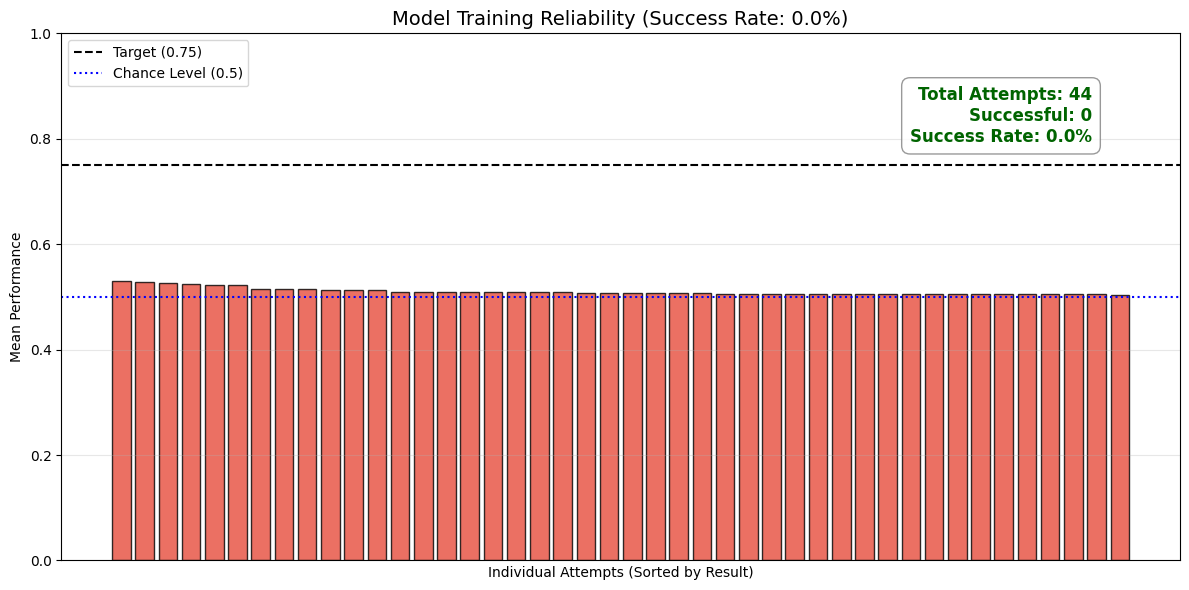

In [387]:
lines = raw_data.strip().split('\n')
parsed = []
for line in lines:
    if not line.strip():
        continue
    parts = line.split(',')
    parsed.append({'name': parts[0], 'mean': float(parts[1]), 'std': float(parts[2])})

df = pd.DataFrame(parsed)

# 2. Sort results to show the distribution of success vs failure
df = df.sort_values(by='mean', ascending=False).reset_index(drop=True)

total_attempts = len(df)
successes = (df['mean'] >= 0.75).sum()
success_rate = (successes / total_attempts) * 100

# 3. Plotting
plt.figure(figsize=(12, 6))

threshold = 0.75
# Color: Green for success, Red for failure
colors = ['#2ecc71' if m >= threshold else '#e74c3c' for m in df['mean']]

plt.bar(range(len(df)), df['mean'], color=colors, edgecolor='black', alpha=0.8)

# Add reference lines
plt.axhline(y=threshold, color='black', linestyle='--', label=f'Target ({threshold})')
plt.axhline(y=0.5, color='blue', linestyle=':', label='Chance Level (0.5)')

stats_text = (
    f"Total Attempts: {total_attempts}\n"
    f"Successful: {successes}\n"
    f"Success Rate: {success_rate:.1f}%"
)

# Place the box in the upper right or upper center
plt.text(
    x=len(df)*0.95, y=0.90, s=stats_text,
    fontsize=12, fontweight='bold', color='darkgreen',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'),
    verticalalignment='top', horizontalalignment='right'
)

# 4. Update Title to be more informative
plt.title(f'Model Training Reliability (Success Rate: {success_rate:.1f}%)', fontsize=14)

plt.ylabel('Mean Performance')
plt.xlabel('Individual Attempts (Sorted by Result)')
plt.ylim(0, 1.0) # Standardize the scale
plt.xticks([])
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
import os
import glob

# Set the directory where your files are located
# Use '.' for the current directory or provide the full path
target_directory = '/home/chunsup2/PycharmProjects/VIBIO/checkpoints/sks_choose/1.0/VIBIO-ABL/Z512T'

# Search for all files containing 'd6_d6'
# This will catch .pth, .png, .json, or log files
files_to_rename = glob.glob(os.path.join(target_directory, "*d6_d6*"))

print(f"Found {len(files_to_rename)} files to rename.\n")

for old_path in files_to_rename:
    # Separate the directory path from the filename
    directory, old_filename = os.path.split(old_path)

    # Create the new filename by replacing 'd6_d6' with 'd6'
    new_filename = old_filename.replace('d6_d6', 'd6')
    new_path = os.path.join(directory, new_filename)

    try:
        os.rename(old_path, new_path)
        print(f"Renamed: {old_filename}  -->  {new_filename}")
    except OSError as e:
        print(f"Error renaming {old_filename}: {e}")

print("\nTask complete.")

Found 10 files to rename.

Renamed: emaVIBCNN_measure_d6_d6_z512_kl0.001_lr0.0005_io1.0_b256_bestAUC.pth  -->  emaVIBCNN_measure_d6_z512_kl0.001_lr0.0005_io1.0_b256_bestAUC.pth
Renamed: emaVIBCNN_measure_d6_d6_z512_kl0.001_lr0.0005_io1.0_b256_bestLoss.pth  -->  emaVIBCNN_measure_d6_z512_kl0.001_lr0.0005_io1.0_b256_bestLoss.pth
Renamed: emaVIBCNN_measure_d6_d6_z512_kl0.001_lr0.0005_io1.0_b256_K_ema_bestAUC.npy  -->  emaVIBCNN_measure_d6_z512_kl0.001_lr0.0005_io1.0_b256_K_ema_bestAUC.npy
Renamed: emaVIBCNN_measure_d6_d6_z512_kl0.001_lr0.0005_io1.0_b256_s_ema_bestAUC.npy  -->  emaVIBCNN_measure_d6_z512_kl0.001_lr0.0005_io1.0_b256_s_ema_bestAUC.npy
Renamed: emaVIBCNN_measure_d6_d6_z512_kl0.001_lr0.0005_io1.0_b256_K_ema_bestLoss.npy  -->  emaVIBCNN_measure_d6_z512_kl0.001_lr0.0005_io1.0_b256_K_ema_bestLoss.npy
Renamed: emaVIBCNN_measure_d6_d6_z512_kl0.001_lr0.0005_io1.0_b256_mu_ema_bestAUC.npy  -->  emaVIBCNN_measure_d6_z512_kl0.001_lr0.0005_io1.0_b256_mu_ema_bestAUC.npy
Renamed: emaVIBCNN_

/tmp/ipykernel_1870213/3079269651.py:46: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(


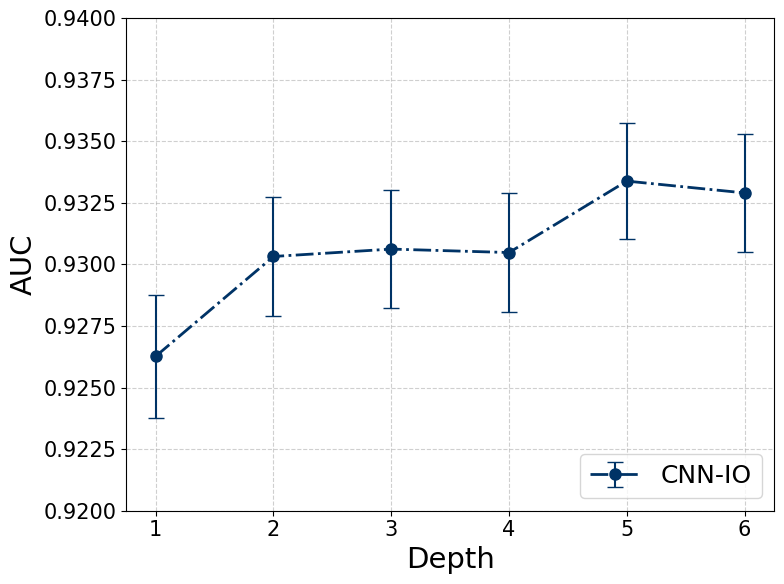

✅ Save path：/home/chunsup2/PycharmProjects/VIBIO/mri_cnnio_depth_auc_sks.png


In [7]:
import matplotlib.pyplot as plt
import os

# ========================
# 1. Data
# ========================
depth = [1, 2, 3, 4, 5, 6, 7]

#

### Best AUC
# AUC
# auc_cnn_io = [0.92627, 0.93032, 0.93062, 0.93048, 0.93338, 0.93290]
# std_cnn_io = [0.00249, 0.00242, 0.00241, 0.00241, 0.00236, 0.00238]

# Standard Deviation (Set to 0 if not available, or remove errorbar)
# std_cnn_io = [0.00264, 0.00258, 0.00243, 0.00256]

# ========================
# 2. Save path
# ========================
save_dir = "/home/chunsup2/PycharmProjects/VIBIO/"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "mri_cnnio_depth_auc_sks.png")

# ========================
# 3. Plot
# ========================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 12,
    'grid.alpha': 0.5,
})

plt.figure(figsize=(8, 6))

# Colors
color_cnn = '#003366'  # Navy Blue

plt.errorbar(
    depth, auc_cnn_io, yerr=std_cnn_io,
    fmt='-o', linestyle='dashdot', capsize=6, linewidth=2.0, markersize=8,
    color=color_cnn, ecolor=color_cnn, elinewidth=1.5,
    label="CNN-IO", zorder=3
)

# Annotations (New Code)
# ========================
# Loop through each data point to add text
for i, x in enumerate(depth):
    y_cnn = auc_cnn_io[i]
    # y_ce = auc_vib_ce[i]
    # y_io = auc_vib_io[i]

    # Format string to 3 or 4 decimal places
    fmt = "{:.4f}"

    # CNN-IO (Blue): Place text slightly below
    # plt.text(x, y_cnn - 0.003, fmt.format(y_cnn),
    #          ha='center', va='top', fontsize=11, color='tab:blue', fontweight='bold')



# ========================
# 4. Labels & style
# ========================
plt.xlabel("Depth", fontsize=21)
plt.ylabel("AUC", fontsize=21)
plt.xticks(depth, fontsize=15)
plt.yticks(fontsize=15)
plt.ylim(0.920, 0.940)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=18, loc='lower right')
plt.margins(y=0.15)
plt.tight_layout()

# ========================
# 5. Save & show
# ========================
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Save path：{save_path}")


/tmp/ipykernel_1870213/3869667271.py:43: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(


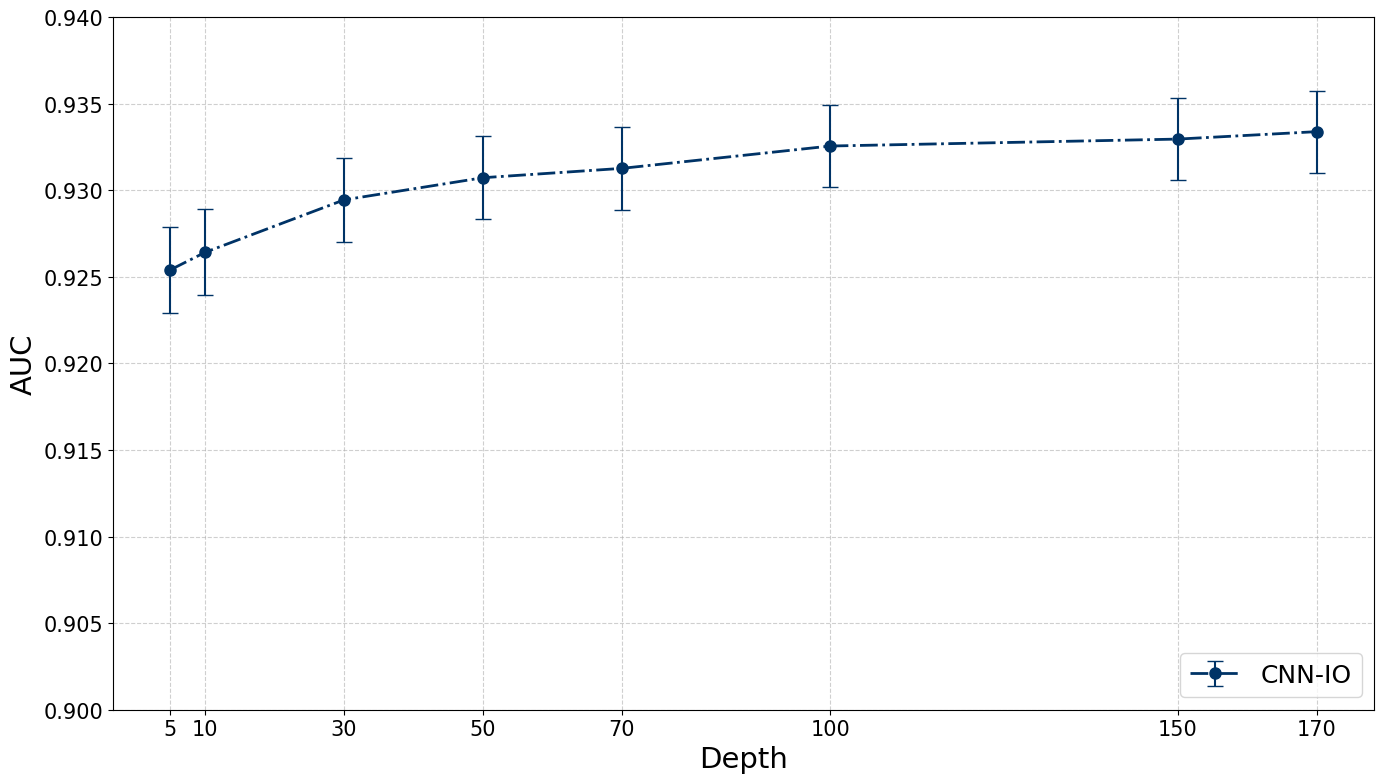

In [15]:
import matplotlib.pyplot as plt
import os

# ========================
# 1. Data
# ========================
data_proportion = [1, 2, 3, 4, 5, 10, 30, 50, 70, 100, 150, 170]
# data_proportion = [5, 10, 30, 50, 70, 100, 150, 170]

### Best AUC
# AUC and Standard Deviation (Set to 0 if not available, or remove errorbar)
# auc_cnn_io = [0.92540, 0.92641, 0.92944, 0.93072, 0.93126, 0.93255, 0.93295, 0.93338]
# std_cnn_io = [0.00250, 0.00248, 0.00244, 0.00240, 0.00240, 0.00238, 0.00236, 0.00236]

auc_cnn_io = [0.50475, 0.912978, 0.534758, 0.915330, 0.916231, 0.917863, ]
std_cnn_io = [0.00375, 0.002771, 0.005618, 0.002679, 0.002678, 0.002655, ]

# ========================
# 2. Save path
# ========================
save_dir = "/home/chunsup2/PycharmProjects/VIBIO/"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "mri_cnnio_depth_auc_sks.png")

# ========================
# 3. Plot
# ========================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 12,
    'grid.alpha': 0.5,
})

plt.figure(figsize=(14, 8))

# Colors
color_cnn = '#003366'  # Navy Blue

plt.errorbar(
    data_proportion, auc_cnn_io, yerr=std_cnn_io,
    fmt='-o', linestyle='dashdot', capsize=6, linewidth=2.0, markersize=8,
    color=color_cnn, ecolor=color_cnn, elinewidth=1.5,
    label="CNN-IO", zorder=3
)

# Annotations (New Code)
# ========================
# Loop through each data point to add text
for i, x in enumerate(data_proportion):
    y_cnn = auc_cnn_io[i]
    # y_ce = auc_vib_ce[i]
    # y_io = auc_vib_io[i]

    # Format string to 3 or 4 decimal places
    fmt = "{:.4f}"

    # CNN-IO (Blue): Place text slightly below
    # plt.text(x, y_cnn - 0.003, fmt.format(y_cnn),
    #          ha='center', va='top', fontsize=11, color='tab:blue', fontweight='bold')



# ========================
# 4. Labels & style
# ========================
plt.xlabel("Depth", fontsize=21)
plt.ylabel("AUC", fontsize=21)
plt.xticks(data_proportion, fontsize=15)
plt.yticks(fontsize=15)
plt.ylim(0.9, 0.940)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=18, loc='lower right')
plt.margins(y=0.15)
plt.tight_layout()

# ========================
# 5. Save & show
# ========================
# plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

# print(f"✅ Save path：{save_path}")
